# MNIST CNN Manifolds

Trains small CNNs on MNIST and inspects encoding + decoding manifolds of the **flattened final conv layer** (32 channels × 5×5 spatial = 800 neurons).

| Condition | Loss | Effect |
|-----------|------|--------|
| **baseline** | CE only | reference |
| **cluster_pref_stim** | CE + L_cluster_pref_stim | supervised contrastive by preferred digit — clusters neurons by tuning preference |

**Encoding manifold plots** (per condition):
1. Neurons coloured by **preferred digit class** (argmax of tuning vector)
2. Neurons coloured by **feature-map channel** (which of the 32 conv2 filters)

Enable lambda values in the **Parameters cell** by editing .  
Checkpoints cached in  — re-running a cell just loads from disk.


In [34]:
# ── Parameters (edit here) ───────────────────────────────────────────────────

MAX_EPOCHS  = 5     # ceiling for early-stopped training
PATIENCE    = 5      # epochs without val CE improvement before stopping
VAL_FRAC    = 0.01     # fraction of train set held out for early stopping
LR          = 1e-3    # Adam learning rate
BATCH_SIZE  = 256     # mini-batch size
SEED        = 1       # random seed for single-model exploration cells
N_PER_CLASS = 50      # test images per class used for manifold evaluation
CKPT_DIR    = '../data/mnist_manifold'

# ── Lambdas to sweep for cluster_pref_stim ────────────────────────────────────
LAMBDAS_PREF_STIM = [10]#[0.001, 0.01, 0.1, 0.5, 1, 5, 10, 50]

# ── Conditions to train ───────────────────────────────────────────────────────
CONDITIONS = {'baseline': 0.0}
for _lam in LAMBDAS_PREF_STIM:
    CONDITIONS[f'cluster_pref_stim_lam{_lam}'] = _lam

# ── Plot colours per condition ────────────────────────────────────────────────
import matplotlib.colors as _mcolors
import matplotlib.cm as _mcm

COND_COLORS = {
    'baseline':             '#555555',
    'cluster_pref_stim':    '#6A1B9A',
}
_cmap = _mcm.get_cmap('Purples', len(LAMBDAS_PREF_STIM) + 3)
for _i, _lam in enumerate(LAMBDAS_PREF_STIM):
    COND_COLORS[f'cluster_pref_stim_lam{_lam}'] = _mcolors.rgb2hex(
        _cmap((_i + 2) / (len(LAMBDAS_PREF_STIM) + 2)))

print(f'Conditions ({len(CONDITIONS)}): {list(CONDITIONS.keys())}')
print(f'Training: early stopping (patience={PATIENCE}, max={MAX_EPOCHS} epochs, val_frac={VAL_FRAC})')


Conditions (2): ['baseline', 'cluster_pref_stim_lam10']
Training: early stopping (patience=5, max=5 epochs, val_frac=0.01)


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_42865/3165519485.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _cmap = _mcm.get_cmap('Purples', len(LAMBDAS_PREF_STIM) + 3)


In [35]:
import sys
import os
_here = os.path.abspath(os.getcwd())
sys.path.insert(0, _here if os.path.isdir(os.path.join(_here, 'src')) else os.path.dirname(_here))
import importlib
import src.mnist_utils
importlib.reload(src.mnist_utils)
import src.subpop_utils
importlib.reload(src.subpop_utils)

import os

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.mnist_utils import (
    CNN, train_or_load_cnn, load_mnist_data,
    compute_tuning_vecs, build_tensor4d,
    encoding_pca, test_accuracy,
    make_neighbor_pairs,
)
from src.subpop_utils import (
    compute_decoding_manifold, knn_decoding_accuracy,
    rdm_correlation, linear_cka,
    procrustes_r2, variance_reproduced,
)

# Device
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'Device: {DEVICE}')

Device: mps


In [36]:
from src.mnist_utils import load_mnist_data_with_val

# ── Load MNIST with validation split for early stopping ───────────────────────
train_loader, val_loader, test_loader = load_mnist_data_with_val(
    batch_size=BATCH_SIZE,
    data_dir=os.path.join(CKPT_DIR, 'raw'),
    val_frac=VAL_FRAC,
    seed=0,   # fixed split seed — same split for all conditions and model seeds
)
print(f'Train: {len(train_loader.dataset):,}   Val: {len(val_loader.dataset):,}   Test: {len(test_loader.dataset):,}')


Train: 59,400   Val: 600   Test: 10,000


## Train / Load models

In [47]:
# ── Train / load all conditions (early stopping on val CE loss) ──────────────
import re as _re

def _base_condition(name):
    m = _re.match(r'^(.+?)_lam[\d.e+-]+$', name)
    return m.group(1) if m else name
SEED = 10
for SEED in [11, 12, 13, 14, 15, 16, 17, 18, 19]:
    models = {}
    for cond, lam in CONDITIONS.items():
        base_cond = _base_condition(cond)
        print(f'\n── {cond}  (base={base_cond})  λ={lam} ──')
        m, _ = train_or_load_cnn(
        base_cond, seed=SEED,
        train_loader=train_loader, ckpt_dir=CKPT_DIR,
        n_epochs=MAX_EPOCHS, lr=LR, device=DEVICE, lam=lam,
        val_loader=val_loader, patience=PATIENCE,
    )
    print(f'  Test accuracy: {test_accuracy(m, test_loader, device=DEVICE):.4f}')
    models[cond] = m



── baseline  (base=baseline)  λ=0.0 ──
  Training CNN baseline  λ=0.0  seed=11  (early-stop (patience=5, max=5)) …
  ep   1/5  ce=0.3768  val_ce=0.1264  val_acc=0.9617  no_imp=0
  ep   2/5  ce=0.0940  val_ce=0.0879  val_acc=0.9783  no_imp=0
  ep   3/5  ce=0.0695  val_ce=0.0665  val_acc=0.9783  no_imp=0
  ep   4/5  ce=0.0559  val_ce=0.0628  val_acc=0.9800  no_imp=0
  ep   5/5  ce=0.0494  val_ce=0.0472  val_acc=0.9733  no_imp=0
  Saved → ../data/mnist_manifold/cnn_baseline_lam0.0_es5_s11.pt

── cluster_pref_stim_lam10  (base=cluster_pref_stim)  λ=10 ──
  Training CNN cluster_pref_stim  λ=10  seed=11  (early-stop (patience=5, max=5)) …
  Pre-flight aux check: cluster_pref_stim loss = 0.034907  (should be non-zero)
  ep   1/5  ce=0.3826  val_ce=0.1266  val_acc=0.9633  L_aux=0.0208  no_imp=0
  ep   2/5  ce=0.1046  val_ce=0.0988  val_acc=0.9733  L_aux=0.0141  no_imp=0
  ep   3/5  ce=0.0812  val_ce=0.0751  val_acc=0.9700  L_aux=0.0123  no_imp=0
  ep   4/5  ce=0.0652  val_ce=0.0830  val_acc=0

## Evaluate manifolds
Build tuning vectors and tensor4d for each model.

In [9]:
MODELS = models   # built by the training cell above
N_CHANNELS = 32
# Geometry helpers — fixed for all conditions (same CNN architecture)
_ref_model    = next(iter(MODELS.values()))
channel_map   = _ref_model.channel_map                        # (800,)  0–31
src_np, dst_np = make_neighbor_pairs(channel_map, _ref_model.spatial_map)

tuning      = {}   # condition → (800, 10)
t4ds        = {}   # condition → (800, 10, N_PER_CLASS, 1)
enc_coords  = {}   # condition → (800, 2)
pref_class  = {}   # condition → (800,)
dec_coords  = {}   # condition → (500, 2)
knn_scores  = {}   # condition → float
accs        = {}   # condition → float
enc_metrics = {}   # condition → {within_ch_var, spatial_var, ch_sep}
stim_lbl    = None

for name, model in MODELS.items():
    print(f'Evaluating {name} …', end=' ', flush=True)
    tuning[name]     = compute_tuning_vecs(model, test_loader, device=DEVICE)
    t4d, sl          = build_tensor4d(model, test_loader,
                                      n_per_class=N_PER_CLASS, device=DEVICE)
    t4ds[name]       = t4d
    if stim_lbl is None:
        stim_lbl = sl
    ec, pc, _        = encoding_pca(tuning[name], n_components=2)
    enc_coords[name] = ec
    pref_class[name] = pc
    dec_coords[name] = compute_decoding_manifold(t4d, n_components=2)[0]
    knn_scores[name] = knn_decoding_accuracy(
        compute_decoding_manifold(t4d, n_components=3)[0], stim_lbl)
    accs[name]       = test_accuracy(model, test_loader, device=DEVICE)

    # ── Encoding manifold metrics ──────────────────────────────────────────
    tv = tuning[name]   # (800, 10)

    # within_ch_var: mean variance of tuning vectors within each channel.
    # LOW → neurons in the same channel have similar tuning (clustered encoding).
    wc_var = float(np.mean([
        tv[channel_map == ch].var(axis=0).mean()
        for ch in range(N_CHANNELS)
    ]))

    # spatial_var: mean squared tuning-vector distance between spatial neighbours.
    # LOW → adjacent feature-map positions have similar tuning (smooth encoding).
    sp_var = float(((tv[src_np] - tv[dst_np]) ** 2).sum(1).mean())

    # ch_sep: mean squared distance between per-channel mean tuning vectors.
    # HIGH → channels are functionally distinct (good for both cluster conditions).
    ch_means = np.stack([tv[channel_map == ch].mean(0) for ch in range(N_CHANNELS)])
    ch_sep   = float(np.mean([
        ((ch_means[i] - ch_means[j]) ** 2).sum()
        for i in range(N_CHANNELS) for j in range(i + 1, N_CHANNELS)
    ]))

    enc_metrics[name] = dict(within_ch_var=wc_var, spatial_var=sp_var, ch_sep=ch_sep)

    print(f'acc={accs[name]:.4f}  knn={knn_scores[name]:.4f}  '
          f'ch_var={wc_var:.4f}  sp_var={sp_var:.4f}  ch_sep={ch_sep:.4f}')

print()
print('Metric guide:')
print('  ch_var  — within-channel tuning variance  (LOW = clustered encoding)')
print('  sp_var  — spatial-neighbour distance      (LOW = smooth encoding)')
print('  ch_sep  — between-channel separation      (HIGH = distinct channels)')


Evaluating baseline … acc=0.9894  knn=0.6380  ch_var=1.5908  sp_var=18.9284  ch_sep=6.1076
Evaluating cluster_pref_stim_lam0.001 … acc=0.9877  knn=0.6500  ch_var=1.5046  sp_var=17.5083  ch_sep=4.1050
Evaluating cluster_pref_stim_lam0.01 … acc=0.9880  knn=0.6440  ch_var=1.5256  sp_var=17.6526  ch_sep=4.1159
Evaluating cluster_pref_stim_lam0.1 … acc=0.9874  knn=0.6400  ch_var=1.5446  sp_var=18.1459  ch_sep=4.0024
Evaluating cluster_pref_stim_lam0.5 … acc=0.9882  knn=0.6320  ch_var=1.7525  sp_var=20.4831  ch_sep=4.4171
Evaluating cluster_pref_stim_lam1 … acc=0.9889  knn=0.6260  ch_var=1.7232  sp_var=20.1269  ch_sep=5.3063
Evaluating cluster_pref_stim_lam5 … acc=0.9882  knn=0.6740  ch_var=1.6257  sp_var=19.1171  ch_sep=7.7003
Evaluating cluster_pref_stim_lam10 … acc=0.9872  knn=0.6700  ch_var=1.4839  sp_var=18.1370  ch_sep=7.0881
Evaluating cluster_pref_stim_lam50 … acc=0.9859  knn=0.6700  ch_var=0.8390  sp_var=10.8505  ch_sep=4.9059

Metric guide:
  ch_var  — within-channel tuning varianc

## Decoding manifolds

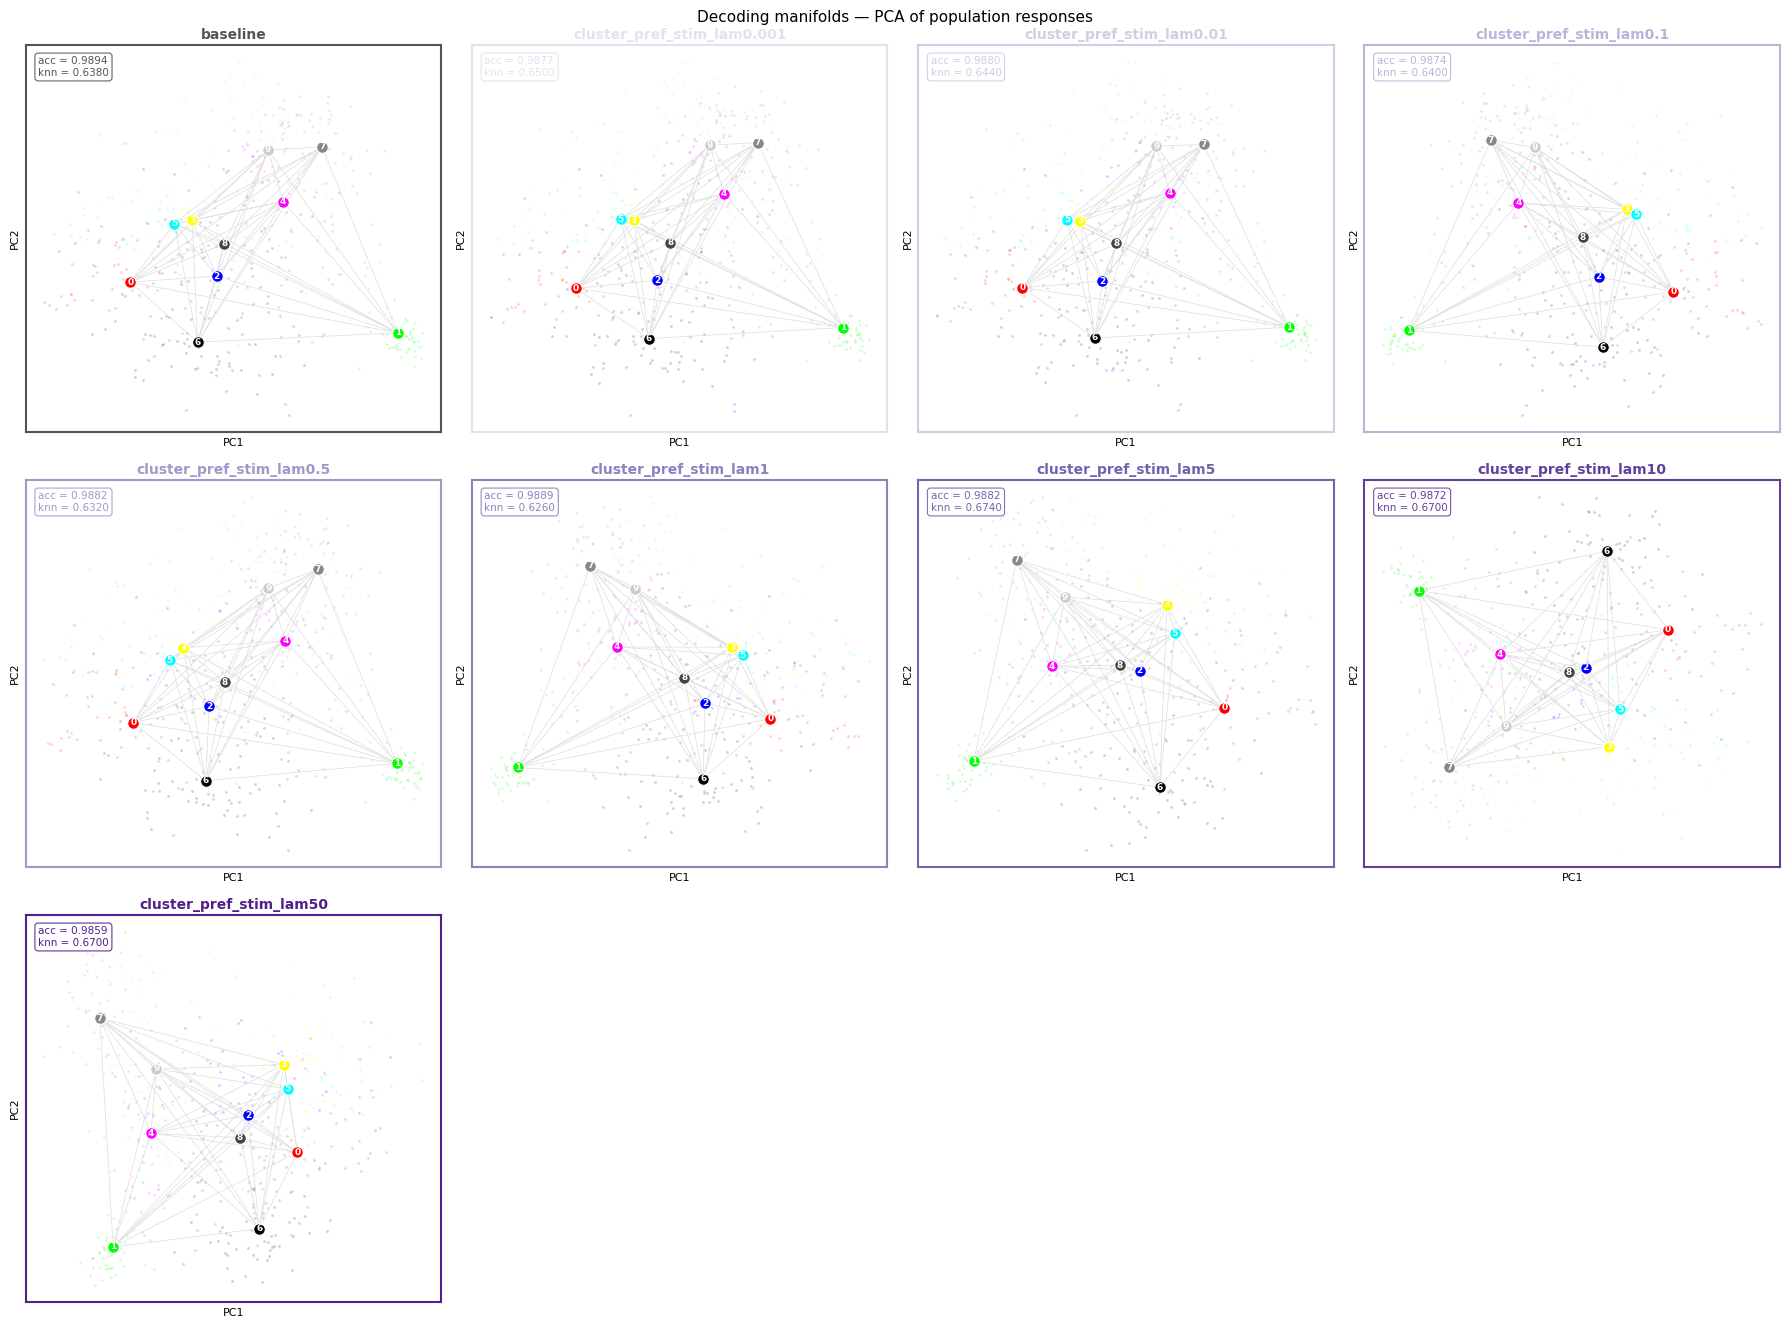

In [10]:
DIGIT_COLORS = {
    0: '#ff0000',
    1: '#00ff00',
    2: '#0000ff',
    3: '#ffff00',
    4: '#ff00ff',
    5: '#00ffff',
    6: '#000000',
    7: '#888888',
    8: '#444444',
    9: '#cccccc'
}
n_cond = len(MODELS)
ncols  = min(n_cond, 4)
nrows  = (n_cond + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes_flat = np.array(axes).flatten() if n_cond > 1 else np.array([axes])
fig.suptitle('Decoding manifolds — PCA of population responses', fontsize=11)

for ax, name in zip(axes_flat, MODELS):
    col = COND_COLORS.get(name, '#888888')
    dc  = dec_coords[name]

    # Individual trial points
    for d in range(10):
        mask = (stim_lbl == d)
        ax.scatter(dc[mask, 0], dc[mask, 1],
                   color=DIGIT_COLORS[d], s=4, alpha=0.18, lw=0)

    # Class centroids
    centroids = np.stack([dc[stim_lbl == d].mean(0) for d in range(10)])

    # Pairwise distance lines
    for i in range(10):
        for j in range(i + 1, 10):
            ax.plot([centroids[i, 0], centroids[j, 0]],
                    [centroids[i, 1], centroids[j, 1]],
                    color='#dddddd', lw=0.5, zorder=1)

    for d in range(10):
        cx, cy = centroids[d]
        ax.scatter(cx, cy, color=DIGIT_COLORS[d], s=70,
                   edgecolors='white', linewidths=0.8, zorder=4)
        ax.text(cx, cy, str(d), fontsize=6.5, color='white',
                ha='center', va='center', fontweight='bold', zorder=5)

    ax.text(0.03, 0.97,
            f'acc = {accs[name]:.4f}\nknn = {knn_scores[name]:.4f}',
            transform=ax.transAxes, fontsize=7.5, color=col, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white',
                      ec=col, alpha=0.9, lw=0.8))

    ax.set_title(name, fontsize=10, fontweight='bold', color=col, pad=4)
    ax.set_xlabel('PC1', fontsize=8); ax.set_ylabel('PC2', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(1.5)

for ax in axes_flat[n_cond:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## Simple Encoding Manifolds (Cosine Similarity)

Fast proxy for the full CP → IAN pipeline: compute pairwise **cosine similarity** between neuron tuning vectors (response profiles across digit classes), then embed with **spectral embedding** on the affinity matrix.

Plotted for **both train and test data** to check whether the encoding topology learned during training generalises to held-out stimuli — a mismatch would indicate the manifold structure is training-set specific.

Train↔test encoding consistency (cosine sim of affinity matrices):
  baseline                   ρ(test,train) = 0.9886
  cluster_pref_stim_lam0.001  ρ(test,train) = 0.9928
  cluster_pref_stim_lam0.01  ρ(test,train) = 0.9929
  cluster_pref_stim_lam0.1   ρ(test,train) = 0.9930
  cluster_pref_stim_lam0.5   ρ(test,train) = 0.9937
  cluster_pref_stim_lam1     ρ(test,train) = 0.9934
  cluster_pref_stim_lam5     ρ(test,train) = 0.9931
  cluster_pref_stim_lam10    ρ(test,train) = 0.9928
  cluster_pref_stim_lam50    ρ(test,train) = 0.9914


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_42865/665753010.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


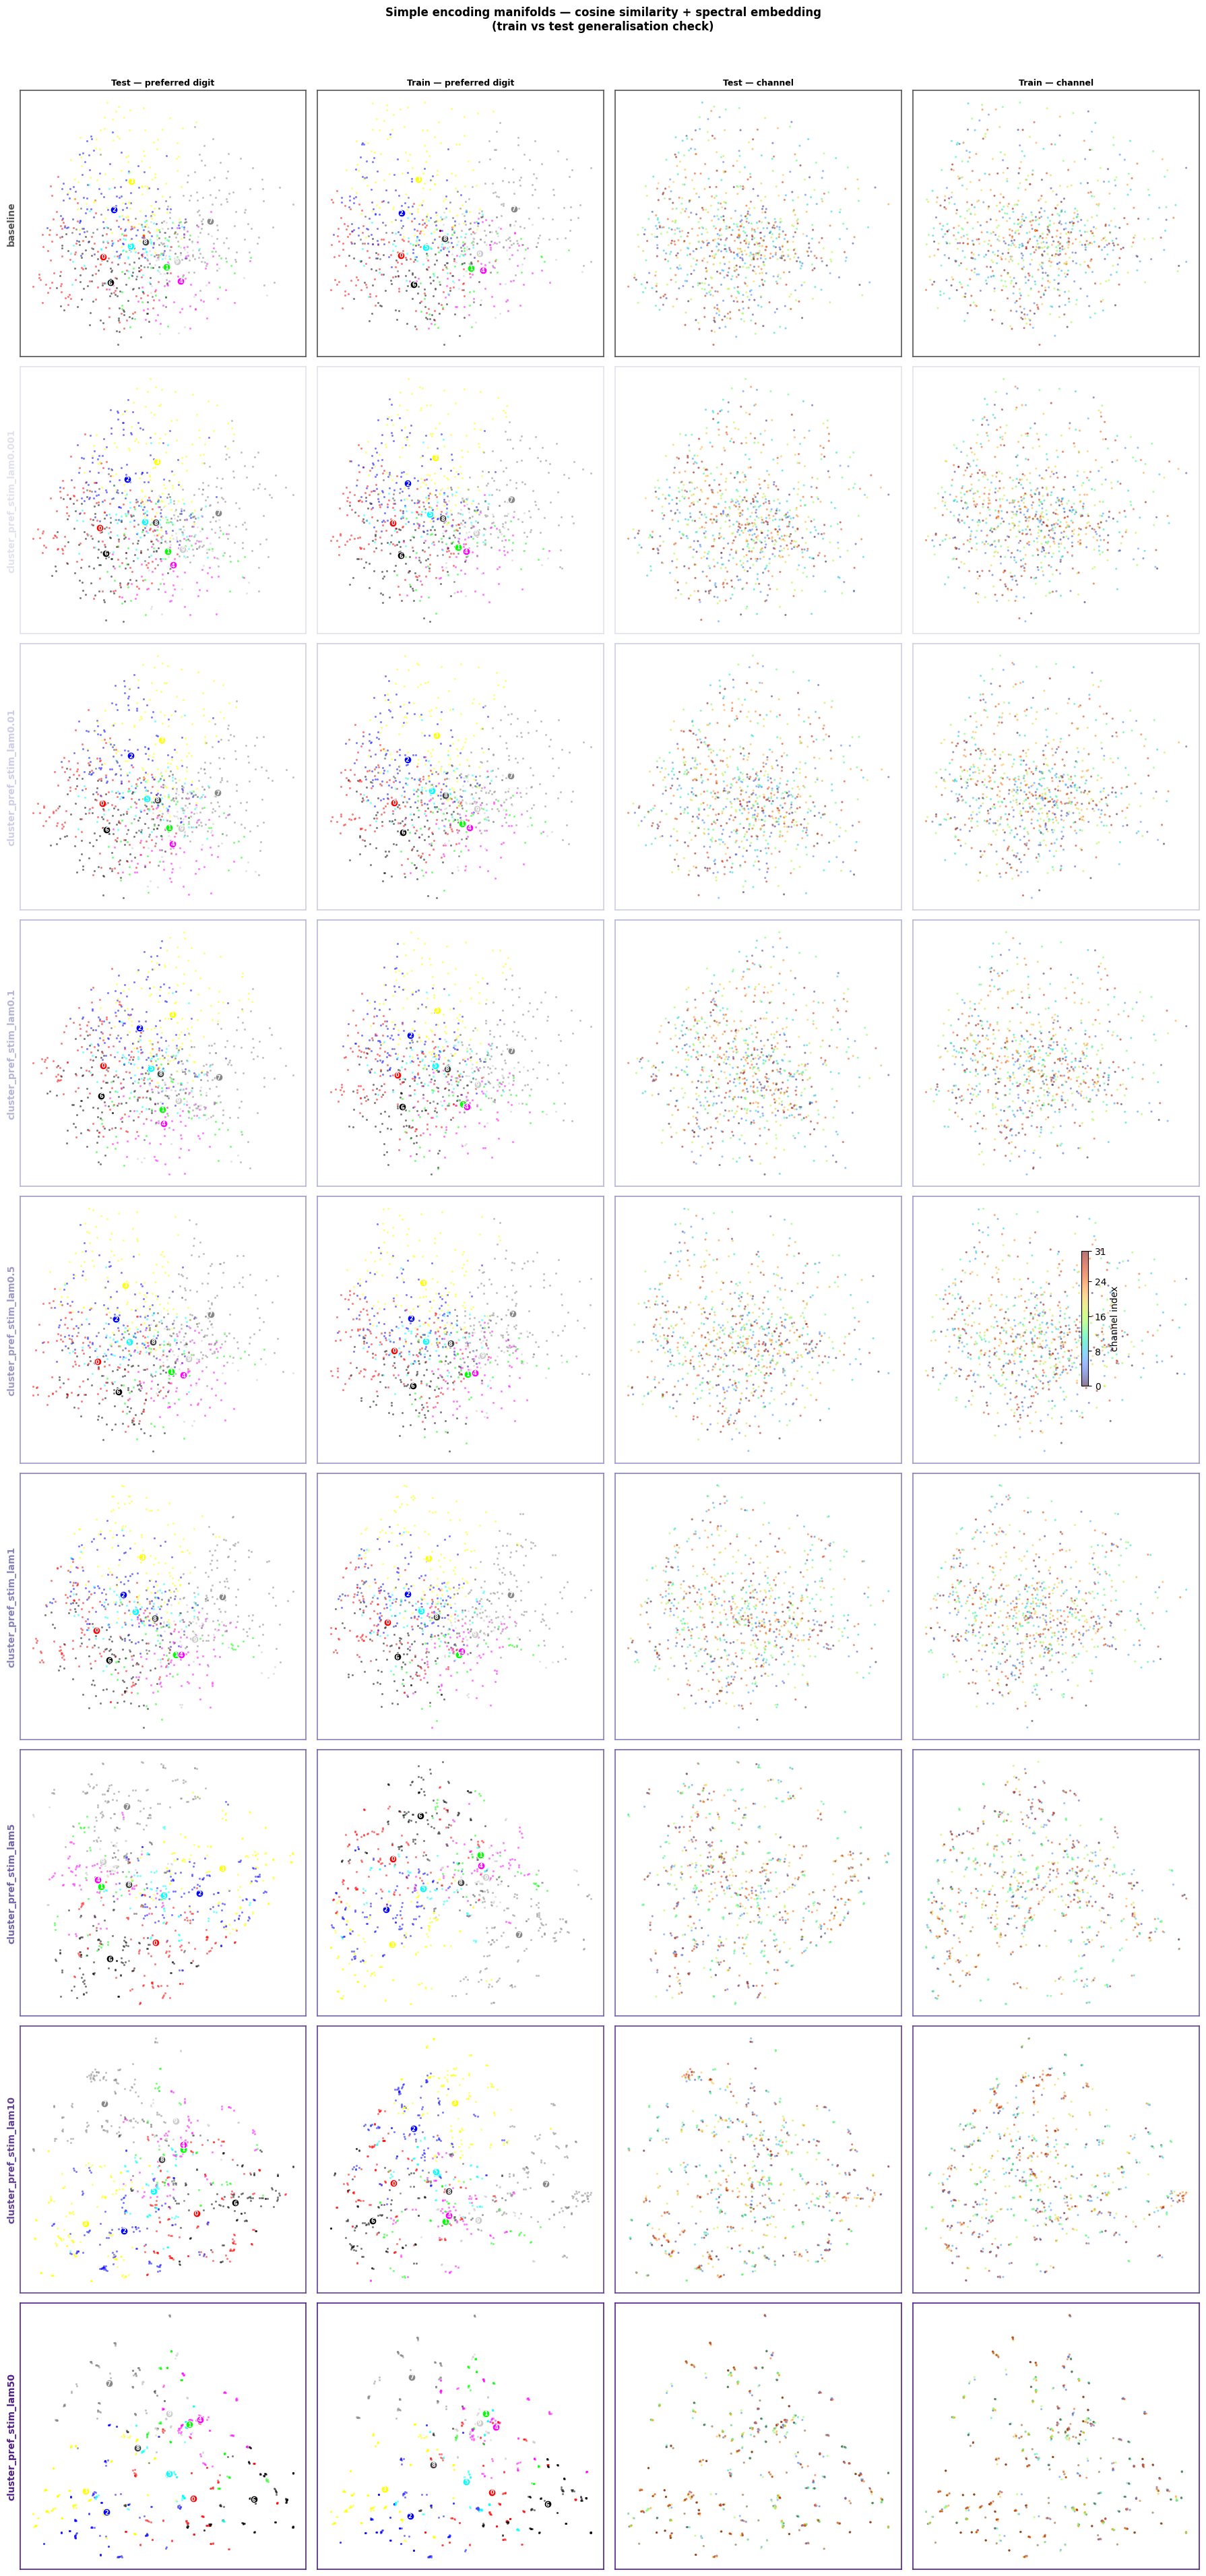

In [11]:
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics.pairwise import cosine_similarity

# ── Compute tuning vectors from TRAIN data as well ───────────────────────────
tuning_train = {}
for name, model in MODELS.items():
    tuning_train[name] = compute_tuning_vecs(model, train_loader, device=DEVICE)

# ── Spectral embedding of cosine-similarity affinity ─────────────────────────
def cosine_spectral_embed(tv, n_components=2, seed=0):
    """Embed neurons via spectral embedding on cosine-similarity affinity.

    Parameters
    ----------
    tv : (N_neurons, n_classes) tuning vectors
    Returns coords (N_neurons, n_components).
    """
    S = cosine_similarity(tv)              # (N, N) in [-1, 1]
    S = (S + 1) / 2                        # shift to [0, 1] for affinity
    np.fill_diagonal(S, 0)                 # no self-loops
    se = SpectralEmbedding(n_components=n_components,
                           affinity='precomputed',
                           random_state=seed)
    return se.fit_transform(S)

# ── Compute embeddings for train & test ──────────────────────────────────────
emb_test  = {}
emb_train = {}
for name in MODELS:
    emb_test[name]  = cosine_spectral_embed(tuning[name])       # test tuning vecs
    emb_train[name] = cosine_spectral_embed(tuning_train[name]) # train tuning vecs

# ── Preferred class for train tuning vectors ─────────────────────────────────
pref_class_train = {name: np.argmax(tv, axis=1) for name, tv in tuning_train.items()}

# ── Plot: 4 rows per condition (test-digit, train-digit, test-channel, train-channel)
n_cond = len(MODELS)
fig, axes = plt.subplots(n_cond, 4, figsize=(18, 4.2 * n_cond))
if n_cond == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('Simple encoding manifolds — cosine similarity + spectral embedding\n'
             '(train vs test generalisation check)',
             fontsize=12, fontweight='bold', y=1.01)

col_titles = ['Test — preferred digit', 'Train — preferred digit',
              'Test — channel', 'Train — channel']

for row, name in enumerate(MODELS):
    col = COND_COLORS.get(name, '#888888')

    for ci, (em, pc_arr, ch_arr, split) in enumerate([
        (emb_test[name],  pref_class[name],       channel_map, 'test'),
        (emb_train[name], pref_class_train[name],  channel_map, 'train'),
    ]):
        ax = axes[row, ci]
        for d in range(10):
            mask = (pc_arr == d)
            ax.scatter(em[mask, 0], em[mask, 1],
                       color=DIGIT_COLORS[d], s=5, alpha=0.5, lw=0)
        # Centroids with digit labels
        for d in range(10):
            mask = (pc_arr == d)
            if not mask.any():
                continue
            cx, cy = em[mask, 0].mean(), em[mask, 1].mean()
            ax.scatter(cx, cy, color=DIGIT_COLORS[d], s=60,
                       edgecolors='white', linewidths=0.7, zorder=5)
            ax.text(cx, cy, str(d), fontsize=6, color='white',
                    ha='center', va='center', fontweight='bold', zorder=6)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(col); sp.set_linewidth(1.2)
        if row == 0:
            ax.set_title(col_titles[ci], fontsize=9, fontweight='bold')

    for ci_ch, (em, ch_arr, split) in enumerate([
        (emb_test[name],  channel_map, 'test'),
        (emb_train[name], channel_map, 'train'),
    ]):
        ax = axes[row, 2 + ci_ch]
        sc = ax.scatter(em[:, 0], em[:, 1],
                        c=ch_arr, cmap='turbo', s=5, alpha=0.55, lw=0,
                        vmin=0, vmax=N_CHANNELS - 1)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_edgecolor(col); sp.set_linewidth(1.2)
        if row == 0:
            ax.set_title(col_titles[2 + ci_ch], fontsize=9, fontweight='bold')

    # Row label
    axes[row, 0].set_ylabel(name, fontsize=10, fontweight='bold', color=col)

# Shared colorbar for channel plots
cb = fig.colorbar(sc, ax=axes[:, 2:].ravel().tolist(), fraction=0.015, pad=0.02,
                  label='channel index')
cb.set_ticks([0, 8, 16, 24, 31])

# ── Quantify train↔test consistency (cosine sim of flattened affinity matrices)
print('Train↔test encoding consistency (cosine sim of affinity matrices):')
for name in MODELS:
    S_test  = cosine_similarity(tuning[name])
    S_train = cosine_similarity(tuning_train[name])
    # Flatten upper triangle and correlate
    mask_ut = np.triu_indices_from(S_test, k=1)
    r = np.corrcoef(S_test[mask_ut], S_train[mask_ut])[0, 1]
    print(f'  {name:25s}  ρ(test,train) = {r:.4f}')

plt.tight_layout()
plt.show()

## CP Encoding Manifolds (full pipeline)

Runs a non-negative permuted CP decomposition on each model's response tensor `(N, 10, N_PER_CLASS)`, then builds the encoding matrix **X** via non-negative least squares.

With `NDIRS=1` (no direction tuning in MNIST) there is no circular shifting; the CP finds F neural response patterns across stimuli and trials.

I skip the exploration across number of factors and use few repititions here for quick exploration.


In [12]:
from sklearn.decomposition import PCA as _PCA
from src.tensor_utils import process_tensor_data, getPermutedTensor, getNeuralMatrix
from src.cp_utils import run_permuted_cp

F_CP     = 10   # CP rank
NREPS_CP = 5   # random restarts (5 = quick preview)

X_cp   = {}  # condition → (N, F_CP) encoding matrix
enc_cp = {}  # condition → (N, 5) PCA of X_cp

for name, model in MODELS.items():
    # t4d: (N, 10, N_PER_CLASS, 1) → (N, 10, 1, N_PER_CLASS) for process_tensor_data
    t4d_fmt = t4ds[name].transpose(0, 1, 3, 2)
    tensorX, _, _ = process_tensor_data(t4d_fmt, optSF=False,
                                         smooth_sig=0, method='relNorm')
    # relNorm divides by each neuron's max — neurons with zero max get NaN; zero them out
    tensorX = np.nan_to_num(tensorX, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'{name}: tensor {tensorX.shape}  '
          f'zero neurons: {(tensorX.sum((1,2)) == 0).sum()}', flush=True)

    result = run_permuted_cp(tensorX, F=F_CP, NDIRS=1,
                              nreps=NREPS_CP, max_iter=200, verbose=True)

    pf, pl = result['all_factors'][0], result['all_lambdas'][0]
    permT, _ = getPermutedTensor(pf, pl, tensorX, NDIRS=1)
    scld = permT / (permT.max() + 1e-12)
    X, _ = getNeuralMatrix(scld, pf, pl, NDIRS=1, all_zeroed_stims=[], verbose=False)
    X_cp[name] = X

    enc_cp[name] = _PCA(n_components=5).fit_transform(X)
    print(f'  X shape: {X.shape}')


baseline: tensor (800, 10, 50)  zero neurons: 25


CP F=10: 100%|██████████| 5/5 [00:11<00:00,  2.29s/it]


  X shape: (800, 10)
cluster_pref_stim_lam0.001: tensor (800, 10, 50)  zero neurons: 1


CP F=10: 100%|██████████| 5/5 [00:13<00:00,  2.65s/it]


  X shape: (800, 10)
cluster_pref_stim_lam0.01: tensor (800, 10, 50)  zero neurons: 1


...

  X shape: (800, 10)
cluster_pref_stim_lam10: tensor (800, 10, 50)  zero neurons: 0


CP F=10: 100%|██████████| 5/5 [00:09<00:00,  1.90s/it]


  X shape: (800, 10)
cluster_pref_stim_lam50: tensor (800, 10, 50)  zero neurons: 0


CP F=10: 100%|██████████| 5/5 [00:10<00:00,  2.02s/it]


  X shape: (800, 10)


## IAN + Diffusion Maps Encoding Manifolds

Runs the same IAN → diffusion-maps → MDS pipeline as notebook 03, but on the
CP encoding matrices `X_cp` built above.  Results cached under `data/mnist_manifold/ian_cache/`.

In [13]:
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from ian.ian import IAN, getSparseMultiScaleK
from ian.embed_utils import diffusionMapSparseK
from src.manifold_utils import compute_mds_embedding
from src.graph_utils import handle_disconnected_points
import os

IAN_CACHE_DIR = os.path.join(CKPT_DIR, 'ian_cache')
os.makedirs(IAN_CACHE_DIR, exist_ok=True)

N_DIFF = 20    # number of diffusion map components to compute
N_MDS  = 5    # MDS components (first 2 used for 2-D plots)
NPCS_IAN = F_CP  # use all CP components as input to IAN

wGs     = {}   # condition → sparse graph
diffmaps = {}  # condition → (N, N_DIFF) diffusion coords
mds_emb  = {}  # condition → (N, N_MDS) MDS coords
ian_nonoutliers = {}  # condition → indices of non-outlier neurons (into original 800)

for name in MODELS:
    print(f'IAN for {name} …', flush=True)
    X_ian = X_cp[name]          # (800, F_CP)
    X_ian += np.random.RandomState(SEED).normal(scale=1e-4, size=X_ian.shape)  # jitter to avoid ties
    #print(X_ian)

    D2 = squareform(pdist(X_ian, 'sqeuclidean'))
    #D2 += 1e-1
    #D2 -= np.diag(D2)  # ensure zeros on diagonal for IAN
    N  = D2.shape[0]

    # ── load IAN from cache or recompute ──────────────────────────────────────
    cache_path = os.path.join(IAN_CACHE_DIR, f'ian_{name}.npz')
    if os.path.exists(cache_path):
        _c = np.load(cache_path, allow_pickle=False)
        wG_dense  = _c['wG']
        wG        = csr_matrix(wG_dense)
        optScales = _c['optScales']
        disc_idxs = _c['disc_pts_indices']
        disc_pts  = [[i] for i in disc_idxs]
        print(f'  loaded cache: {cache_path}')
    else:
        G, wG, optScales, disc_pts = IAN('exact-precomputed-sq', D2, solver=None, verbose=1)
        disc_idxs = np.array([disc_pts[di][0] for di in range(len(disc_pts))], dtype=np.int64)
        np.savez(cache_path, wG=wG.toarray(), optScales=optScales, disc_pts_indices=disc_idxs)
        print(f'  cached → {cache_path}')

    # ── handle disconnected points ────────────────────────────────────────────
    outliers_ian  = np.array([], dtype=int)
    nonoutliers_ian = np.arange(N)
    G_bin = (wG.toarray() > 0).astype(float)

    if len(disc_pts) > 0:
        wG, G_bin, outliers_ian, nonoutliers_ian, _ = handle_disconnected_points(
            disc_pts, optScales, G_bin, D2, outliers_ian,
            np.column_stack([np.arange(N), np.zeros(N)]),   # dummy neurons_used
            X_ian)
    else:
        wG = getSparseMultiScaleK(D2, optScales)

    wGs[name] = wG
    ian_nonoutliers[name] = nonoutliers_ian  # store per-condition

    # ── diffusion map ─────────────────────────────────────────────────────────
    dm_y, dm_evals = diffusionMapSparseK(csr_matrix(wG), N_DIFF, alpha=1, t=1)
    diffmaps[name] = dm_y

    # ── MDS embedding ─────────────────────────────────────────────────────────
    mds_emb[name] = compute_mds_embedding(dm_y, NPCS_IAN, n_components=N_MDS)

    print(f'  done — nonoutliers: {len(nonoutliers_ian)}/{N}')

IAN for baseline …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_baseline.npz
  done — nonoutliers: 800/800
IAN for cluster_pref_stim_lam0.001 …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_cluster_pref_stim_lam0.001.npz
  done — nonoutliers: 800/800
IAN for cluster_pref_stim_lam0.01 …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_cluster_pref_stim_lam0.01.npz
  done — nonoutliers: 800/800
IAN for cluster_pref_stim_lam0.1 …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_cluster_pref_stim_lam0.1.npz
  done — nonoutliers: 800/800
IAN for cluster_pref_stim_lam0.5 …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_cluster_pref_stim_lam0.5.npz
  done — nonoutliers: 800/800
IAN for cluster_pref_stim_lam1 …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_cluster_pref_stim_lam1.npz
  done — nonoutliers: 800/800
IAN for cluster_pref_stim_lam5 …
  loaded cache: ../data/mnist_manifold/ian_cache/ian_cluster_pref_stim_lam5.npz
  done — nonoutliers: 800/800
IAN f

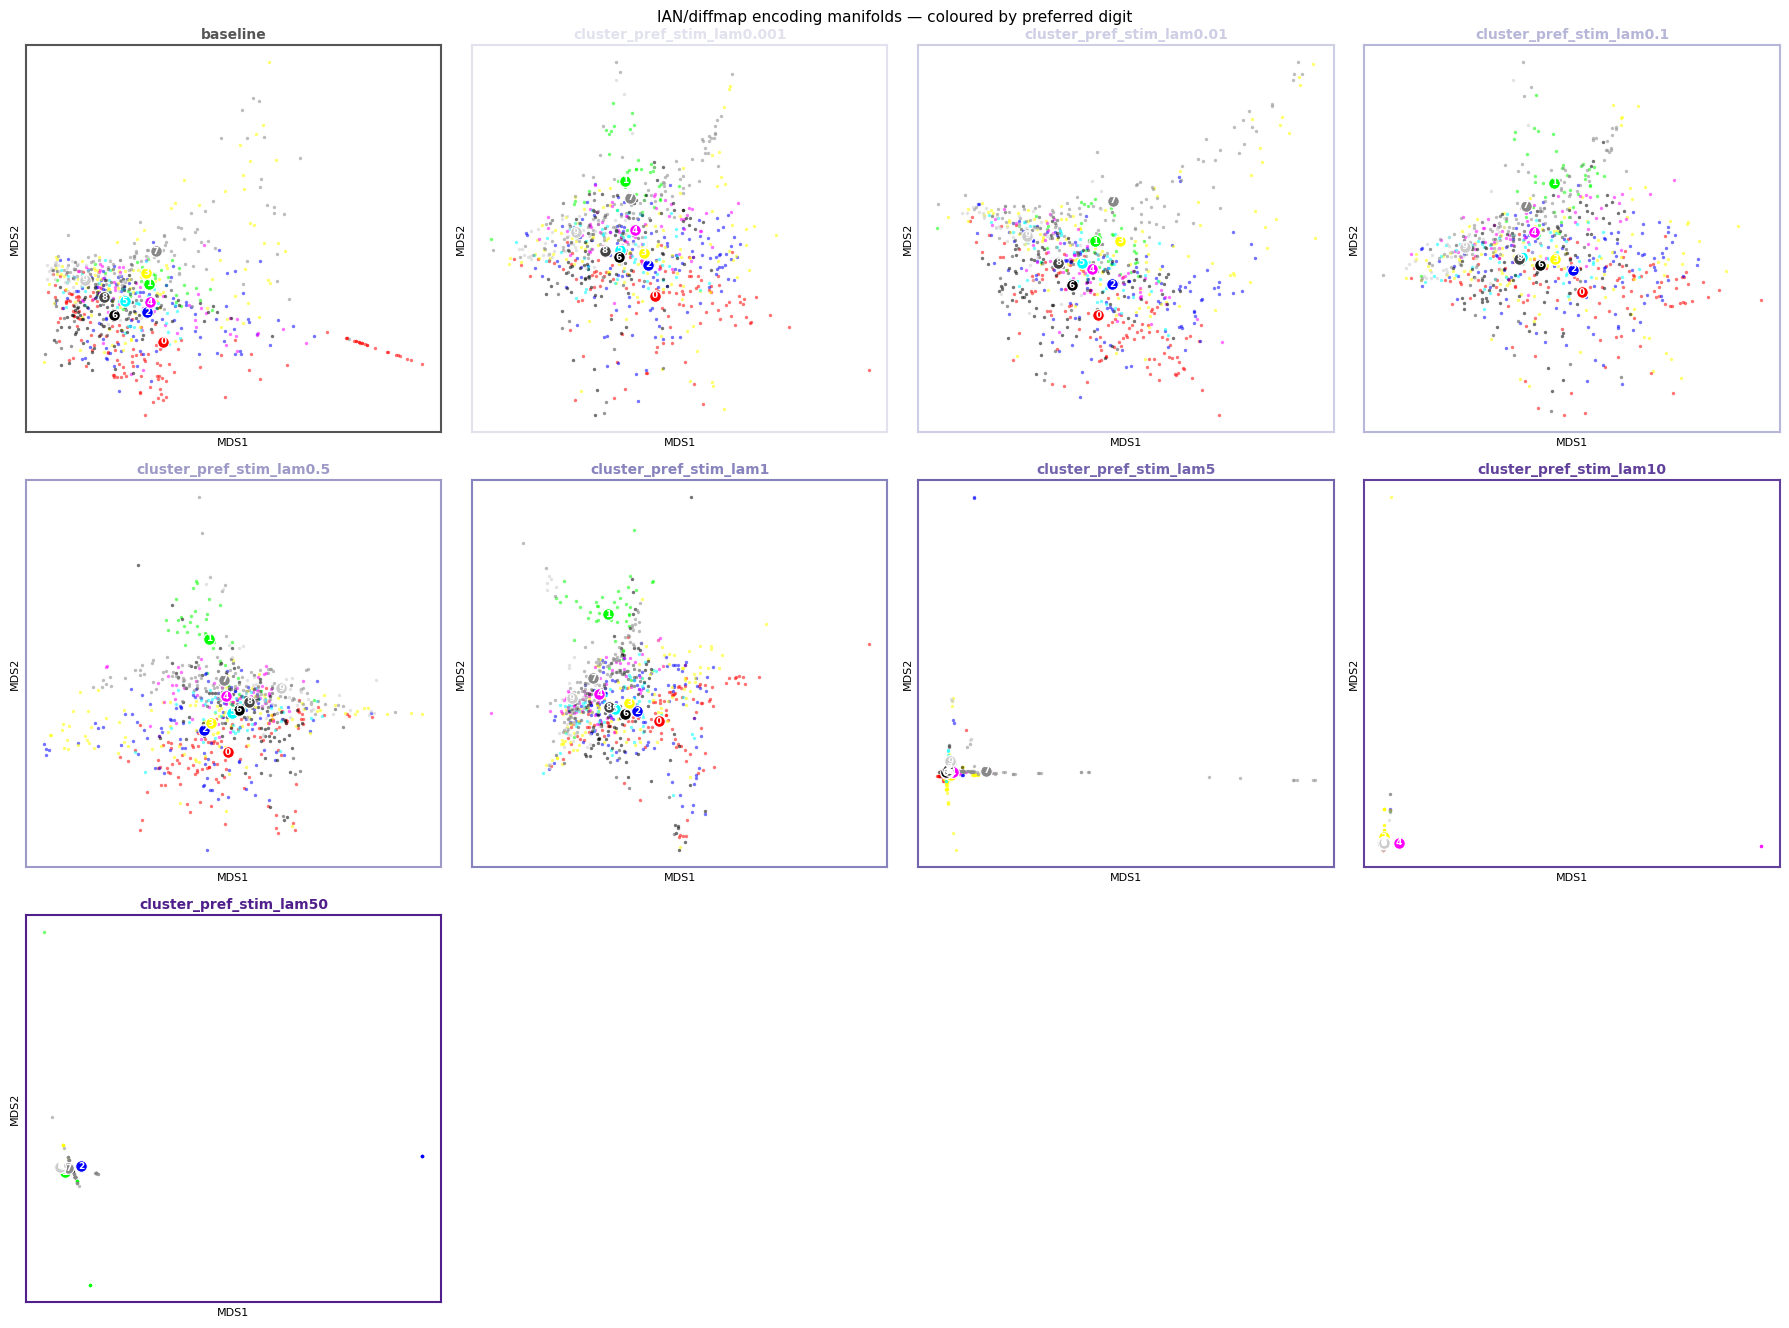

In [14]:
n_cond = len(MODELS)
ncols  = min(n_cond, 4)
nrows  = (n_cond + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes_flat = np.array(axes).flatten() if n_cond > 1 else np.array([axes])
fig.suptitle('IAN/diffmap encoding manifolds — coloured by preferred digit', fontsize=11)

for ax, name in zip(axes_flat, MODELS):
    col = COND_COLORS.get(name, '#888888')
    em  = mds_emb[name][:, :2]
    # Filter to non-outlier neurons (IAN may remove disconnected points)
    keep = ian_nonoutliers[name]
    pc   = pref_class[name][keep]

    for d in range(10):
        mask = (pc == d)
        ax.scatter(em[mask, 0], em[mask, 1],
                   color=DIGIT_COLORS[d], s=6, alpha=0.55, lw=0)

    for d in range(10):
        mask = (pc == d)
        if not mask.any():
            continue
        cx, cy = em[mask, 0].mean(), em[mask, 1].mean()
        ax.scatter(cx, cy, color=DIGIT_COLORS[d], s=70,
                   edgecolors='white', linewidths=0.8, zorder=5)
        ax.text(cx, cy, str(d), fontsize=6.5, color='white',
                ha='center', va='center', fontweight='bold', zorder=6)

    ax.set_title(name, fontsize=10, fontweight='bold', color=col, pad=4)
    ax.set_xlabel('MDS1', fontsize=8); ax.set_ylabel('MDS2', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(1.5)

for ax in axes_flat[n_cond:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_42865/1149212293.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


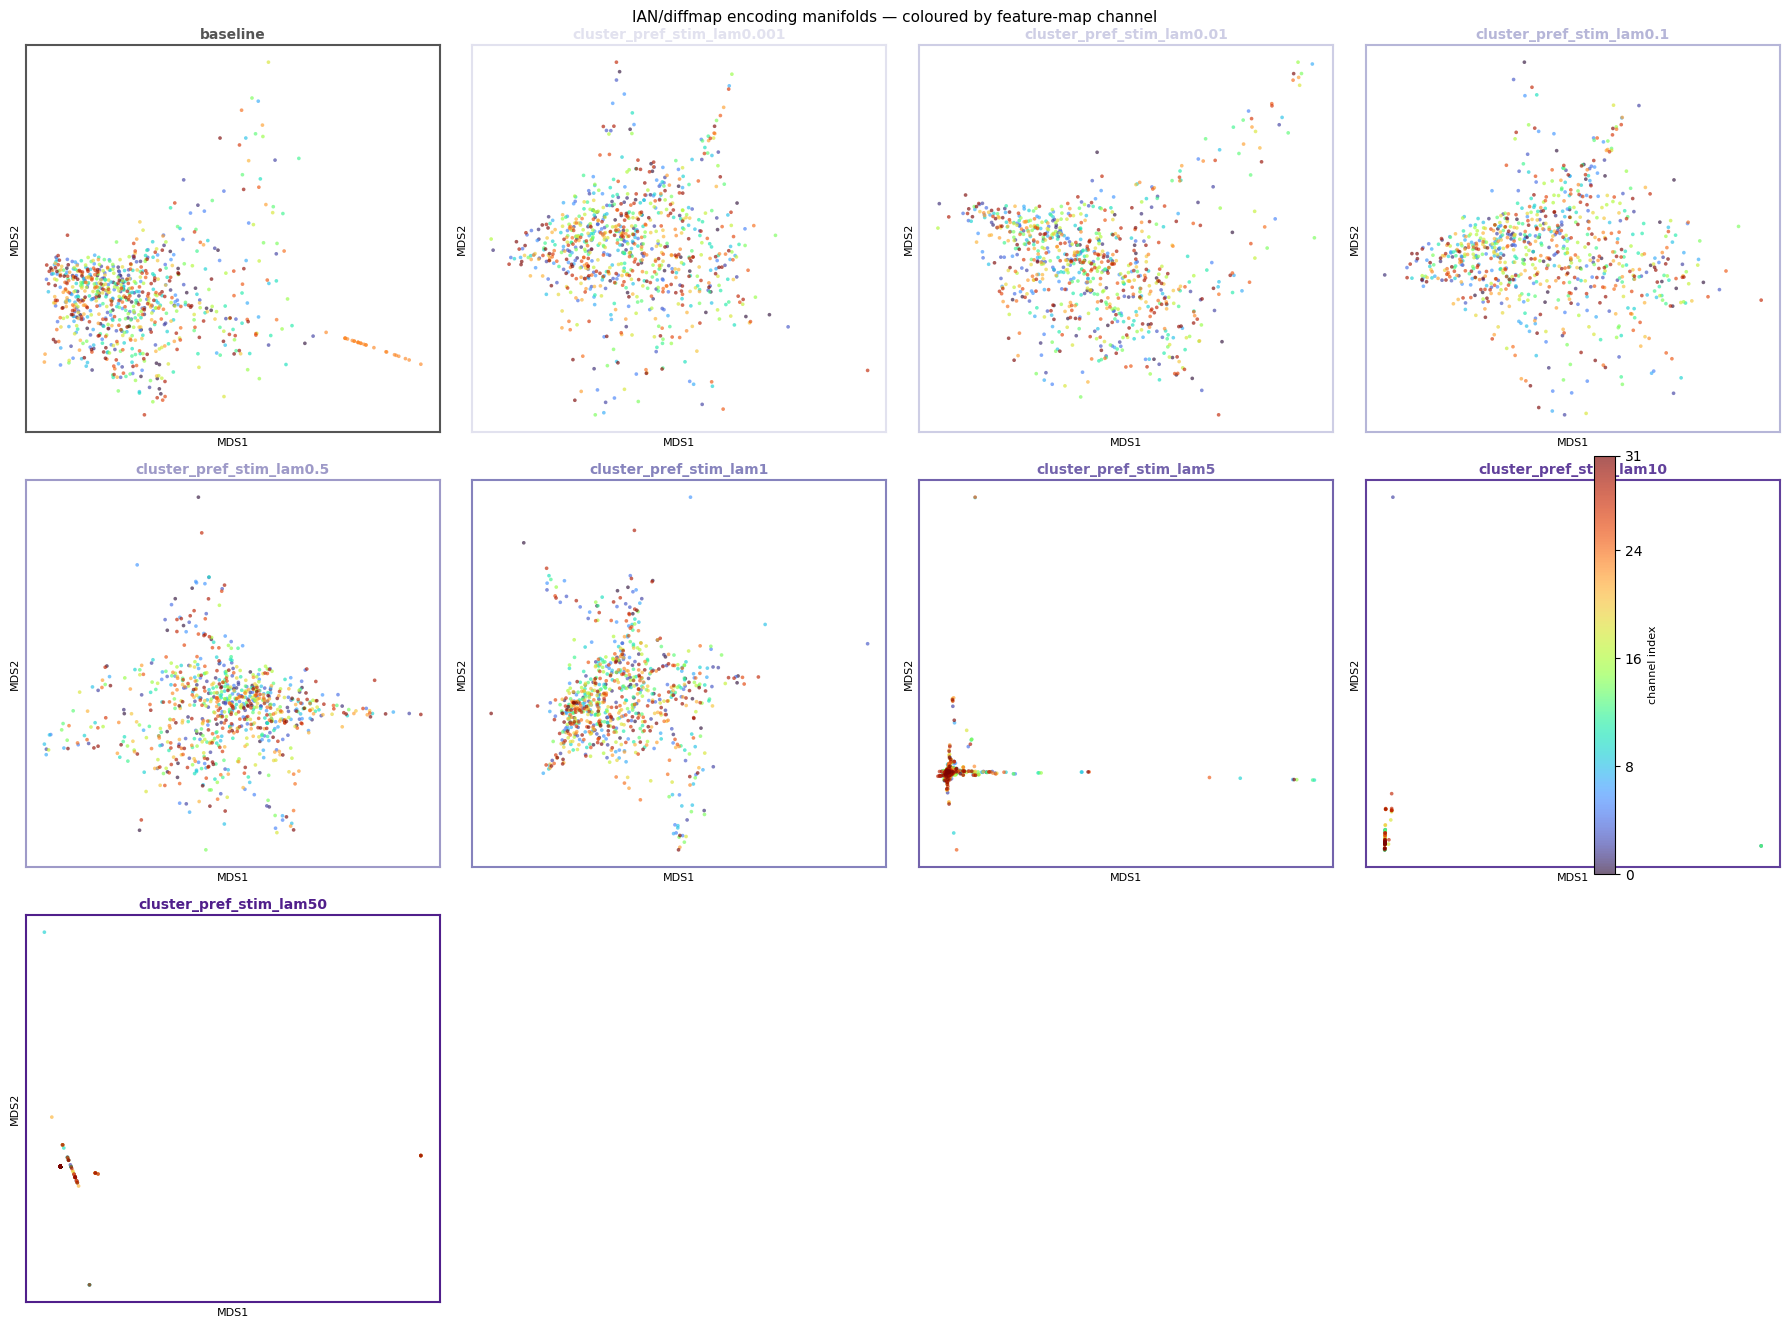

In [15]:
n_cond = len(MODELS)
ncols  = min(n_cond, 4)
nrows  = (n_cond + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4.5 * nrows))
axes_flat = np.array(axes).flatten() if n_cond > 1 else np.array([axes])
fig.suptitle('IAN/diffmap encoding manifolds — coloured by feature-map channel', fontsize=11)

sc = None
for ax, name in zip(axes_flat, MODELS):
    col = COND_COLORS.get(name, '#888888')
    em  = mds_emb[name][:, :2]
    # Filter to non-outlier neurons (IAN may remove disconnected points)
    keep = ian_nonoutliers[name]
    ch   = channel_map[keep]

    sc = ax.scatter(em[:, 0], em[:, 1],
                    c=ch, cmap='turbo', s=7, alpha=0.65, lw=0,
                    vmin=0, vmax=N_CHANNELS - 1)

    ax.set_title(name, fontsize=10, fontweight='bold', color=col, pad=4)
    ax.set_xlabel('MDS1', fontsize=8); ax.set_ylabel('MDS2', fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(1.5)

for ax in axes_flat[n_cond:]:
    ax.set_visible(False)

if sc is not None:
    cb = fig.colorbar(sc, ax=axes_flat[:n_cond].tolist(), fraction=0.015, pad=0.02)
    cb.set_label('channel index', fontsize=8)
    cb.set_ticks([0, 8, 16, 24, 31])

plt.tight_layout()
plt.show()

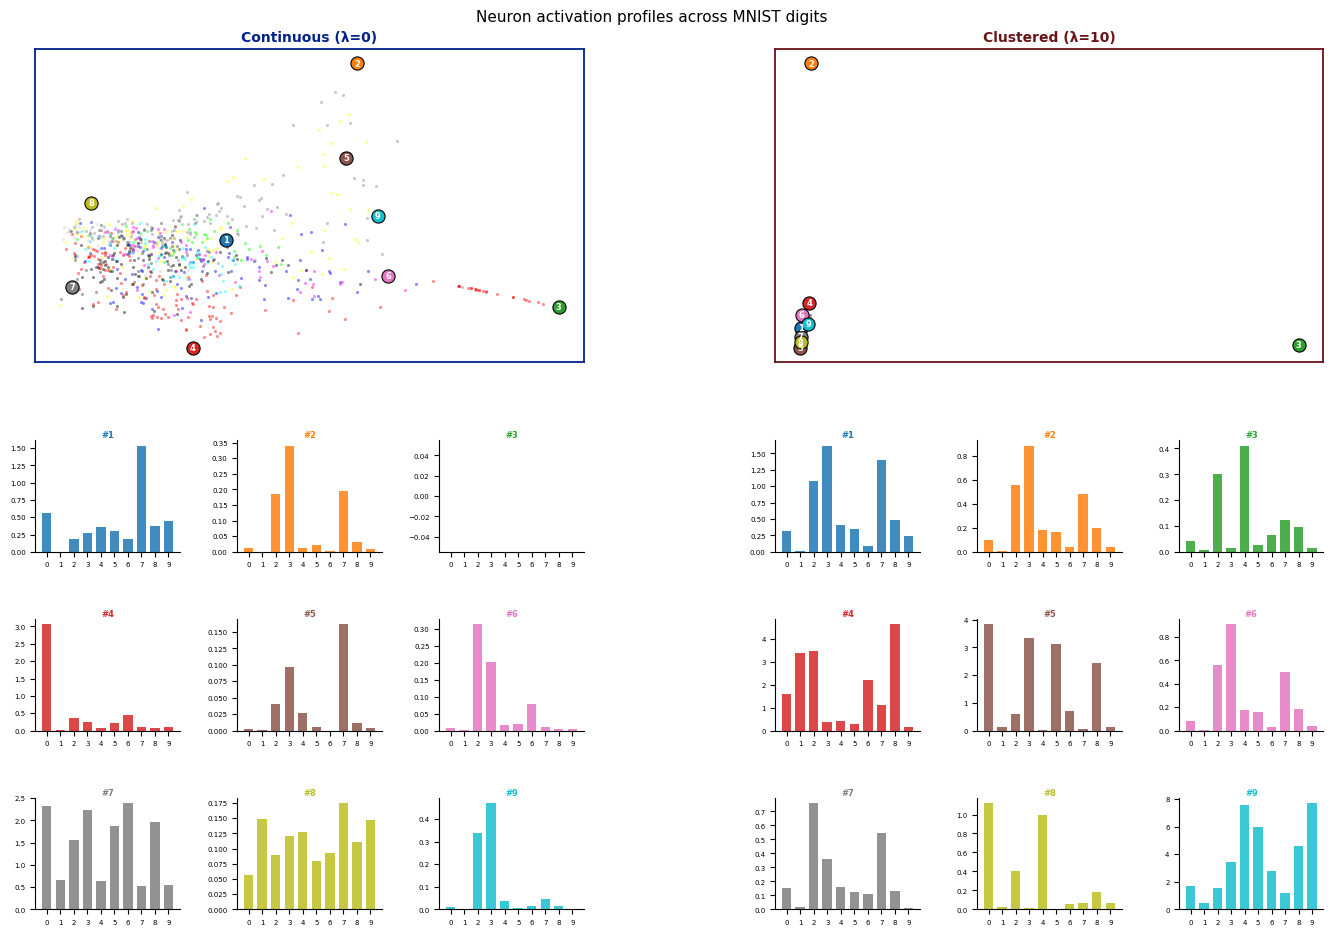

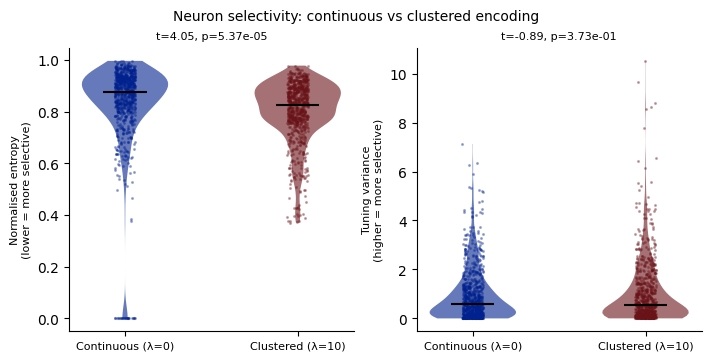

Baseline  — median entropy: 0.878  median variance: 0.5993
Clustered — median entropy: 0.828  median variance: 0.5557


In [16]:
## Neuron selectivity: activation bar plots + entropy/variance comparison

_CONDS_SEL  = ['baseline', 'cluster_pref_stim_lam10']
_N_SAMPLE   = 9     # neurons to highlight per condition
_RNG_SEL    = np.random.default_rng(7)
_COND_COLOR = {'baseline': '#00218e', 'cluster_pref_stim_lam10': '#691318'}
_COND_LABEL = {'baseline': 'Continuous (λ=0)', 'cluster_pref_stim_lam10': 'Clustered (λ=10)'}

# ── Helper: normalised entropy of tuning vector ─────────────────────────────
def tuning_entropy(tv):
    """Normalised entropy (0=fully selective, 1=uniform) of abs(tuning) across digits."""
    w = np.abs(tv)
    s = w.sum(axis=1, keepdims=True) + 1e-8
    p = w / s
    p = np.clip(p, 1e-8, 1.0)
    return (-np.sum(p * np.log(p), axis=1)) / np.log(tv.shape[1])

def tuning_variance(tv):
    """Variance of tuning responses across digits (mean-subtracted)."""
    return tv.var(axis=1)

# ── Figure layout ───────────────────────────────────────────────────────────
fig_s = plt.figure(figsize=(14, 10))
gs_s  = fig_s.add_gridspec(
    4, len(_CONDS_SEL),
    height_ratios=[3, 1, 1, 1],
    hspace=0.50, wspace=0.35,
    left=0.06, right=0.98, top=0.94, bottom=0.08,
)

entropy_all  = {}
variance_all = {}

for ci, name in enumerate(_CONDS_SEL):
    keep = ian_nonoutliers[name]           # indices into 800-neuron space
    em   = mds_emb[name][:, :2]           # (N_keep, 2)
    tv   = tuning[name][keep]              # (N_keep, 10)
    pc   = pref_class[name][keep]

    entropy_all[name]  = tuning_entropy(tv)
    variance_all[name] = tuning_variance(tv)

    # Sample neurons spread across the manifold via k-means-like farthest-point
    N_keep = len(em)
    chosen = [int(_RNG_SEL.integers(N_keep))]
    dists  = np.linalg.norm(em - em[chosen[0]], axis=1)
    for _ in range(_N_SAMPLE - 1):
        chosen.append(int(np.argmax(dists)))
        dists = np.minimum(dists, np.linalg.norm(em - em[chosen[-1]], axis=1))
    chosen = np.array(chosen)

    # Manifold panel
    ax_m = fig_s.add_subplot(gs_s[0, ci])
    for d in range(10):
        mask = (pc == d)
        ax_m.scatter(em[mask, 0], em[mask, 1],
                     color=DIGIT_COLORS[d], s=5, alpha=0.45, lw=0)
    sample_colors = plt.cm.tab10(np.linspace(0, 1, _N_SAMPLE))
    for ni, sidx in enumerate(chosen):
        ax_m.scatter(em[sidx, 0], em[sidx, 1],
                     color=sample_colors[ni], s=90, edgecolors='black',
                     linewidths=0.8, zorder=5)
        ax_m.text(em[sidx, 0], em[sidx, 1], str(ni + 1),
                  fontsize=6, ha='center', va='center',
                  fontweight='bold', zorder=6, color='white')
    ax_m.set_title(_COND_LABEL[name], fontsize=10, fontweight='bold',
                   color=_COND_COLOR[name])
    ax_m.set_xticks([]); ax_m.set_yticks([])
    for sp in ax_m.spines.values():
        sp.set_edgecolor(_COND_COLOR[name]); sp.set_linewidth(1.3)

    # Bar plots (3 rows × 3 cols below each manifold)
    for ni, sidx in enumerate(chosen):
        row = 1 + ni // 3
        col_in_group = ni % 3
        # Create inner gridspec for 3×3 bar plots under this condition column
        if ci == 0 and ni == 0:
            inner = gs_s[1:, 0].subgridspec(3, 3, hspace=0.6, wspace=0.4)
        elif ci == 1 and ni == 0:
            inner = gs_s[1:, 1].subgridspec(3, 3, hspace=0.6, wspace=0.4)
        ax_b = fig_s.add_subplot(inner[ni // 3, col_in_group])
        bars = ax_b.bar(np.arange(10), tv[sidx], color=sample_colors[ni],
                        width=0.7, edgecolor='none', alpha=0.85)
        ax_b.set_xticks(np.arange(10)); ax_b.set_xticklabels(list('0123456789'), fontsize=5)
        ax_b.tick_params(axis='y', labelsize=5)
        ax_b.set_title(f'#{ni+1}', fontsize=6, fontweight='bold', pad=2,
                       color=sample_colors[ni])
        ax_b.spines['top'].set_visible(False)
        ax_b.spines['right'].set_visible(False)

fig_s.suptitle('Neuron activation profiles across MNIST digits', fontsize=11)
plt.savefig(os.path.join(CKPT_DIR, 'neuron_selectivity_barcharts.pdf'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── Selectivity quantification ──────────────────────────────────────────────
from scipy import stats as _stats

fig_q, axes_q = plt.subplots(1, 2, figsize=(7, 3.5), constrained_layout=True)

for ax, (metric_name, data_dict) in zip(axes_q, [
    ('Normalised entropy\n(lower = more selective)', entropy_all),
    ('Tuning variance\n(higher = more selective)', variance_all),
]):
    vals = [data_dict[n] for n in _CONDS_SEL]
    colors = [_COND_COLOR[n] for n in _CONDS_SEL]
    labels = [_COND_LABEL[n] for n in _CONDS_SEL]

    parts = ax.violinplot(vals, positions=[0, 1], showmedians=True,
                          showextrema=False)
    for pc_obj, c in zip(parts['bodies'], colors):
        pc_obj.set_facecolor(c); pc_obj.set_alpha(0.6)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(1.5)

    # Overlay jittered strip
    for xi, (v, c) in enumerate(zip(vals, colors)):
        jitter = np.random.default_rng(42).uniform(-0.06, 0.06, len(v))
        ax.scatter(xi + jitter, v, color=c, s=1.5, alpha=0.3)

    # t-test
    t, p = _stats.ttest_ind(vals[0], vals[1], equal_var=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel(metric_name, fontsize=8)
    ax.set_title(f't={t:.2f}, p={p:.2e}', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig_q.suptitle('Neuron selectivity: continuous vs clustered encoding', fontsize=10)
plt.savefig(os.path.join(CKPT_DIR, 'neuron_selectivity_stats.pdf'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Baseline  — median entropy: {np.median(entropy_all['baseline']):.3f}  "
      f"median variance: {np.median(variance_all['baseline']):.4f}")
print(f"Clustered — median entropy: {np.median(entropy_all['cluster_pref_stim_lam10']):.3f}  "
      f"median variance: {np.median(variance_all['cluster_pref_stim_lam10']):.4f}")


## Metrics vs λ (compared to baseline)

All metrics are computed **pairwise against baseline** and plotted as a function of λ.

**Decoding metrics** (should remain high if encoding change doesn't affect readout):
- **RSA** — Spearman ρ of RDMs (M2)
- **CKA** — linear centred kernel alignment (M3)
- **Procrustes R²** — shape similarity after rigid alignment in PCA space (M4)
- **Variance Reproduced** — ratio of PCA variance to baseline (M5)

**Encoding metrics** (should show clear change as λ increases):
- **GW Similarity (CP)** — normalized Gromov–Wasserstein on CP encoding matrices
- **GW Similarity (IAN)** — normalized GW on IAN/diffusion-map MDS embeddings
- **Silhouette Score** — clusteredness of MDS embedding by preferred digit

GW is normalized to a similarity in [0, 1]: `sim = 1 − GW(cond, baseline) / GW_max`, where `GW_max = GW(baseline, collapsed)` (all points at centroid).

GW_max (CP, baseline vs collapsed): 1.739003
GW_max (IAN, baseline vs collapsed): 0.148943

── Metrics for cluster_pref_stim_lam0.001 (λ=0.001) vs baseline ──
  RSA=0.9944  CKA=0.9965  ProcR2=nan  VarRep=0.9411
  GW_CP=0.060476 → sim=0.9652   GW_IAN=0.007610 → sim=0.9489
  Silhouette=-0.1665

── Metrics for cluster_pref_stim_lam0.01 (λ=0.01) vs baseline ──
  RSA=0.9940  CKA=0.9962  ProcR2=nan  VarRep=0.9503
  GW_CP=0.058735 → sim=0.9662   GW_IAN=0.005656 → sim=0.9620
  Silhouette=-0.1806

── Metrics for cluster_pref_stim_lam0.1 (λ=0.1) vs baseline ──
  RSA=0.9944  CKA=0.9961  ProcR2=nan  VarRep=0.9779
  GW_CP=0.061440 → sim=0.9647   GW_IAN=0.007939 → sim=0.9467
  Silhouette=-0.1810

── Metrics for cluster_pref_stim_lam0.5 (λ=0.5) vs baseline ──
  RSA=0.9932  CKA=0.9959  ProcR2=nan  VarRep=1.1216
  GW_CP=0.051816 → sim=0.9702   GW_IAN=0.007930 → sim=0.9468
  Silhouette=-0.1530

── Metrics for cluster_pref_stim_lam1 (λ=1) vs baseline ──
  RSA=0.9866  CKA=0.9923  ProcR2=nan  VarRep=1.1349

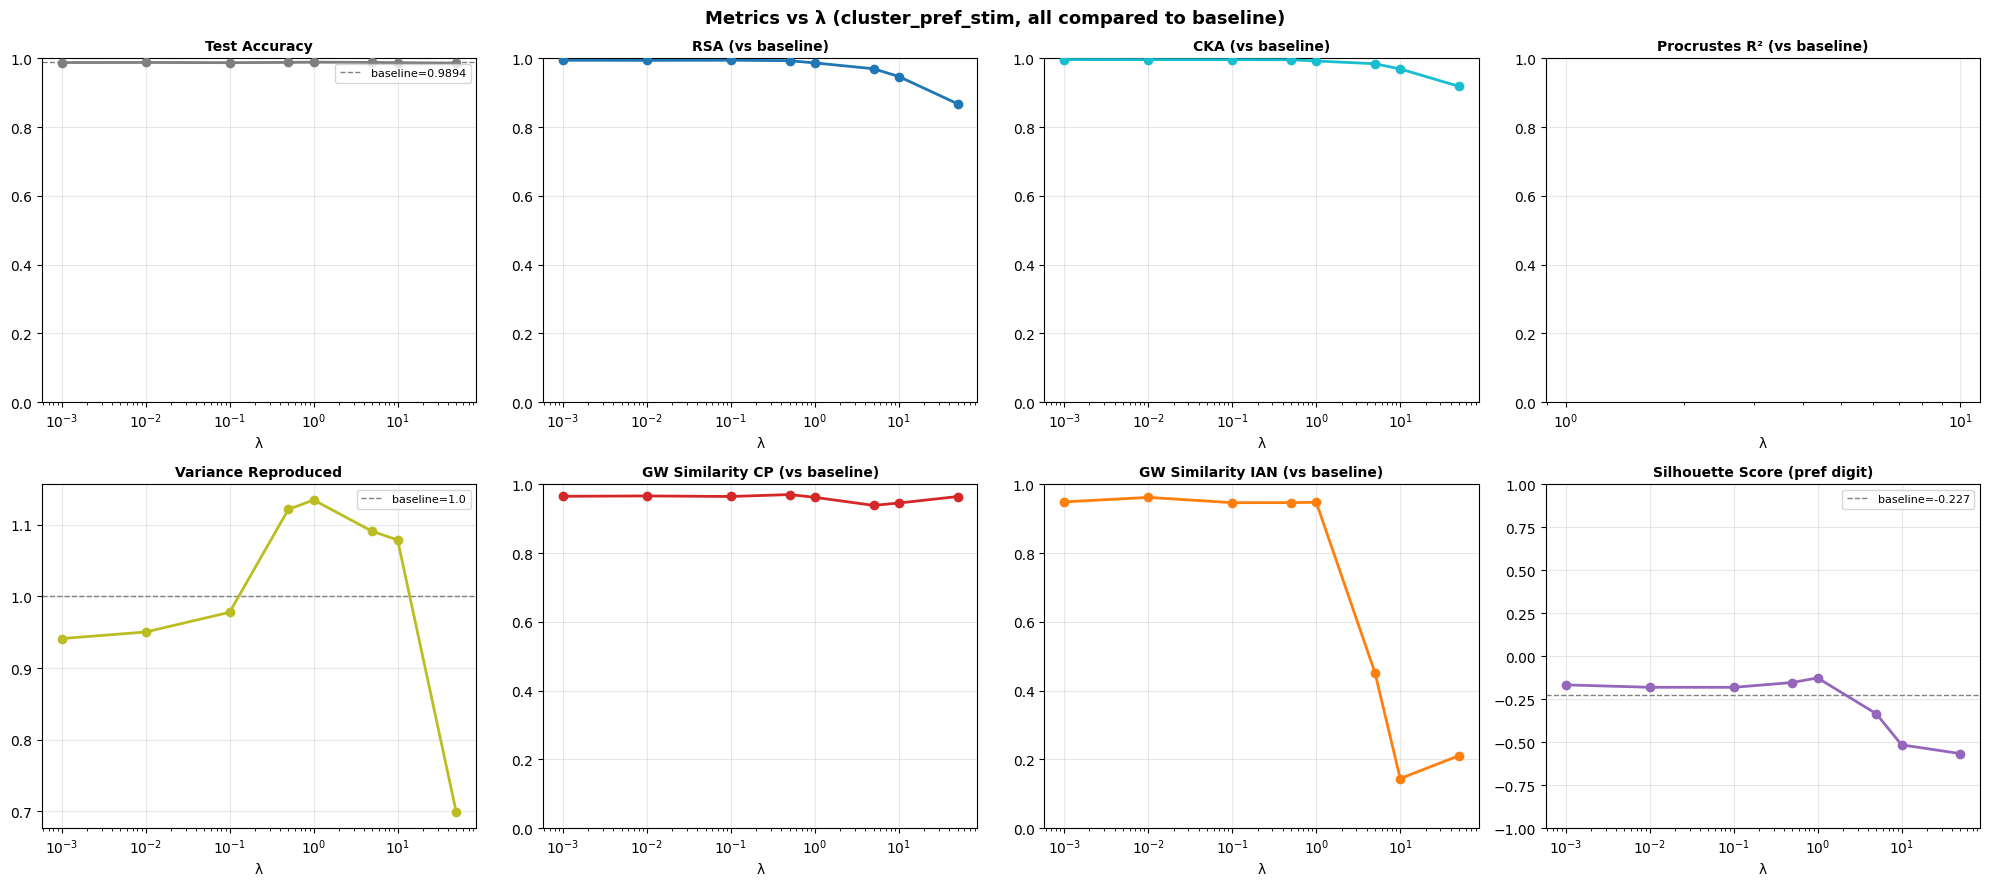


Condition                           λ    Acc    RSA    CKA  ProcR²  VarRep  GW_CP  GW_IAN   Silh
────────────────────────────────────────────────────────────────────────────────────────────────────
baseline                            0 0.9894  1.000  1.000   1.000   1.000  1.000   1.000 -0.2270
cluster_pref_stim_lam0.001      0.001 0.9877 0.9944 0.9965     nan  0.9411 0.9652  0.9489 -0.1665
cluster_pref_stim_lam0.01        0.01 0.9880 0.9940 0.9962     nan  0.9503 0.9662  0.9620 -0.1806
cluster_pref_stim_lam0.1          0.1 0.9874 0.9944 0.9961     nan  0.9779 0.9647  0.9467 -0.1810
cluster_pref_stim_lam0.5          0.5 0.9882 0.9932 0.9959     nan  1.1216 0.9702  0.9468 -0.1530
cluster_pref_stim_lam1              1 0.9889 0.9866 0.9923     nan  1.1349 0.9621  0.9478 -0.1260
cluster_pref_stim_lam5              5 0.9882 0.9697 0.9843     nan  1.0910 0.9388  0.4523 -0.3346
cluster_pref_stim_lam10            10 0.9872 0.9470 0.9690     nan  1.0790 0.9457  0.1442 -0.5155
cluster_pref_stim

In [17]:
from sklearn.metrics import silhouette_score
from src.mnist_utils import encoding_gw_distance

# ── Normalisation reference for GW ───────────────────────────────────────────
# GW_max = GW(baseline, collapsed), where "collapsed" = all points at centroid.
# This is the worst-case topology mismatch for the same number of points.
_X_baseline_cp = X_cp['baseline']
_X_collapsed = np.full_like(_X_baseline_cp, _X_baseline_cp.mean(0))
# Add tiny jitter so OT solver doesn't choke on zero distances
_X_collapsed += np.random.RandomState(42).normal(scale=1e-8, size=_X_collapsed.shape)
gw_max_cp = encoding_gw_distance(_X_baseline_cp, _X_collapsed,
                                  n_subsample=300, rng_seed=0)
print(f'GW_max (CP, baseline vs collapsed): {gw_max_cp:.6f}')

_mds_baseline = mds_emb['baseline']
_mds_collapsed = np.full_like(_mds_baseline, _mds_baseline.mean(0))
_mds_collapsed += np.random.RandomState(42).normal(scale=1e-8, size=_mds_collapsed.shape)
gw_max_ian = encoding_gw_distance(_mds_baseline, _mds_collapsed,
                                   n_subsample=300, rng_seed=0)
print(f'GW_max (IAN, baseline vs collapsed): {gw_max_ian:.6f}')

# ── Collect metrics for each condition vs baseline ───────────────────────────
cond_names_lam = [c for c in CONDITIONS if c != 'baseline']
lambdas = [CONDITIONS[c] for c in cond_names_lam]

metrics = {
    'lambda':       lambdas,
    'condition':    cond_names_lam,
    'accuracy':     [],
    'rsa':          [],
    'cka':          [],
    'procrustes_r2': [],
    'var_reproduced': [],
    'gw_sim_cp':    [],
    'gw_sim_ian':   [],
    'silhouette':   [],
}

for name in cond_names_lam:
    lam_val = CONDITIONS[name]
    print(f'\n── Metrics for {name} (λ={lam_val}) vs baseline ──')

    # Decoding metrics
    rsa = rdm_correlation(t4ds['baseline'], t4ds[name])
    cka = linear_cka(t4ds['baseline'], t4ds[name])
    proc = procrustes_r2(t4ds['baseline'], t4ds[name])
    vrep = variance_reproduced_from_tensor(t4ds['baseline'], t4ds[name], n_components=3)
    metrics['rsa'].append(rsa)
    metrics['cka'].append(cka)
    metrics['procrustes_r2'].append(proc)
    metrics['var_reproduced'].append(vrep)
    metrics['accuracy'].append(accs[name])
    print(f'  RSA={rsa:.4f}  CKA={cka:.4f}  ProcR2={proc:.4f}  VarRep={vrep:.4f}')

    # Encoding GW (normalised to similarity)
    gw_cp = encoding_gw_distance(X_cp['baseline'], X_cp[name],
                                  n_subsample=300, rng_seed=0)
    gw_ian = encoding_gw_distance(mds_emb['baseline'], mds_emb[name],
                                   n_subsample=min(300, min(len(mds_emb['baseline']),
                                                            len(mds_emb[name]))),
                                   rng_seed=0)
    sim_cp  = float(np.clip(1.0 - gw_cp / gw_max_cp, 0, 1))
    sim_ian = float(np.clip(1.0 - gw_ian / gw_max_ian, 0, 1))
    metrics['gw_sim_cp'].append(sim_cp)
    metrics['gw_sim_ian'].append(sim_ian)
    print(f'  GW_CP={gw_cp:.6f} → sim={sim_cp:.4f}   '
          f'GW_IAN={gw_ian:.6f} → sim={sim_ian:.4f}')

    # Silhouette score on IAN/MDS embedding by preferred digit
    keep = ian_nonoutliers[name]
    emb_2d = mds_emb[name][:, :2]
    labels = pref_class[name][keep]
    if len(np.unique(labels)) >= 2:
        sil = float(silhouette_score(emb_2d, labels))
    else:
        sil = 0.0
    metrics['silhouette'].append(sil)
    print(f'  Silhouette={sil:.4f}')

# Baseline silhouette for reference
keep_bl = ian_nonoutliers['baseline']
emb_bl = mds_emb['baseline'][:, :2]
lbl_bl = pref_class['baseline'][keep_bl]
sil_bl = float(silhouette_score(emb_bl, lbl_bl)) if len(np.unique(lbl_bl)) >= 2 else 0.0
print(f'\nBaseline silhouette: {sil_bl:.4f}')
print(f'Baseline accuracy:  {accs["baseline"]:.4f}')

# ── Plot: metrics vs λ ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Metrics vs λ (cluster_pref_stim, all compared to baseline)',
             fontsize=13, fontweight='bold')

plot_specs = [
    ('accuracy',       'Test Accuracy',           [0, 1],  'tab:gray',   False),
    ('rsa',            'RSA (vs baseline)',        [0, 1],  'tab:blue',   False),
    ('cka',            'CKA (vs baseline)',        [0, 1],  'tab:cyan',   False),
    ('procrustes_r2',  'Procrustes R² (vs baseline)', [0, 1], 'tab:green', False),
    ('var_reproduced', 'Variance Reproduced',      None,    'tab:olive',  True),
    ('gw_sim_cp',      'GW Similarity CP (vs baseline)', [0, 1], 'tab:red', False),
    ('gw_sim_ian',     'GW Similarity IAN (vs baseline)', [0, 1], 'tab:orange', False),
    ('silhouette',     'Silhouette Score (pref digit)', [-1, 1], 'tab:purple', True),
]

for ax, (key, title, ylim, color, show_baseline) in zip(axes.flat, plot_specs):
    vals = metrics[key]
    ax.semilogx(lambdas, vals, 'o-', color=color, lw=2, ms=6, zorder=3)
    if show_baseline and key == 'silhouette':
        ax.axhline(sil_bl, ls='--', color='gray', lw=1, label=f'baseline={sil_bl:.3f}')
        ax.legend(fontsize=8)
    elif show_baseline and key == 'var_reproduced':
        ax.axhline(1.0, ls='--', color='gray', lw=1, label='baseline=1.0')
        ax.legend(fontsize=8)
    elif key == 'accuracy':
        ax.axhline(accs['baseline'], ls='--', color='gray', lw=1,
                   label=f'baseline={accs["baseline"]:.4f}')
        ax.legend(fontsize=8)
    if ylim:
        ax.set_ylim(ylim)
    ax.set_xlabel('λ', fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print(f'\n{"Condition":<30s} {"λ":>6s} {"Acc":>6s} {"RSA":>6s} {"CKA":>6s} '
      f'{"ProcR²":>7s} {"VarRep":>7s} {"GW_CP":>6s} {"GW_IAN":>7s} {"Silh":>6s}')
print('─' * 100)
print(f'{"baseline":<30s} {"0":>6s} {accs["baseline"]:>6.4f} {"1.000":>6s} {"1.000":>6s} '
      f'{"1.000":>7s} {"1.000":>7s} {"1.000":>6s} {"1.000":>7s} {sil_bl:>6.4f}')
for i, name in enumerate(cond_names_lam):
    print(f'{name:<30s} {lambdas[i]:>6.3g} {metrics["accuracy"][i]:>6.4f} '
          f'{metrics["rsa"][i]:>6.4f} {metrics["cka"][i]:>6.4f} '
          f'{metrics["procrustes_r2"][i]:>7.4f} {metrics["var_reproduced"][i]:>7.4f} '
          f'{metrics["gw_sim_cp"][i]:>6.4f} {metrics["gw_sim_ian"][i]:>7.4f} '
          f'{metrics["silhouette"][i]:>6.4f}')

## Paper figure — baseline vs cluster_pref_stim_lam10

6
[0.9944006439779737, 0.994041668613395, 0.9944411008027881, 0.9931875334782537, 0.9865740290601489, 0.9696948760134143, 0.9469923243359731, 0.8676933069025684]
0.14415931584924413 0.9469923243359731 0.9690374032112999


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


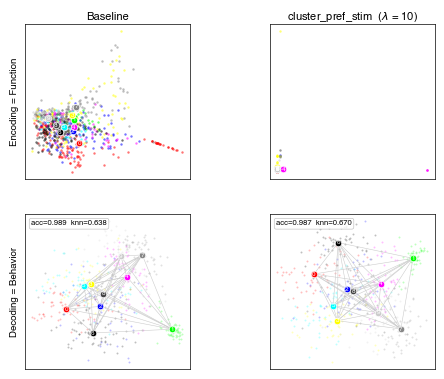

Saved → ../data/mnist_manifold/fig_baseline_vs_lam10.pdf


In [18]:
# ── Paper-ready 2×2 figure  (encoding top, decoding bottom) ─────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

FIG_CONDS  = ['baseline', 'cluster_pref_stim_lam10']
COL_TITLES = ['Baseline', r'cluster_pref_stim  ($\lambda$ = 10)']
OUT_PATH   = os.path.join(CKPT_DIR, 'fig_baseline_vs_lam10.pdf')

# ── Look up comparison metrics for lam10 vs baseline ─────────────────────────
_idx  = metrics['condition'].index('cluster_pref_stim_lam10')
print(_idx)
print(metrics['rsa'])
_rsa  = metrics['rsa'][_idx]
_cka  = metrics['cka'][_idx]
_gw   = metrics['gw_sim_ian'][_idx]

# ── rcParams for publication ─────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         7,
    'axes.titlesize':    8,
    'axes.labelsize':    7,
    'xtick.labelsize':   6,
    'ytick.labelsize':   6,
    'legend.fontsize':   6,
    'pdf.fonttype':      42,
    'ps.fonttype':       42,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
})

W_COL   = 1.65   # inches per panel
H_ENC   = 1.55   # encoding row height  (top)
H_DEC   = 1.55   # decoding row height  (bottom)
HSPACE  = 0.35   # vertical gap between rows
WSPACE  = 0.80   # horizontal gap — wide enough to hold central annotation text
LMARGIN = 0.30
RMARGIN = 0.10
TMARGIN = 0.30
BMARGIN = 0.30

fig_w = LMARGIN + 2 * W_COL + WSPACE + RMARGIN
fig_h = TMARGIN + H_ENC + HSPACE + H_DEC + BMARGIN

fig = plt.figure(figsize=(fig_w, fig_h))

l = LMARGIN / fig_w
r = 1 - RMARGIN / fig_w
t = 1 - TMARGIN / fig_h
b = BMARGIN / fig_h

gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    left=l, right=r, top=t, bottom=b,
    hspace=HSPACE / ((H_ENC + H_DEC) / 2),
    wspace=WSPACE / W_COL,
)

ax = [[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)]

for col, cond in enumerate(FIG_CONDS):

    # ── Encoding manifold (row 0 — top) ──────────────────────────────────────
    a    = ax[0][col]
    keep = ian_nonoutliers[cond]
    em   = mds_emb[cond][:, :2]
    pc   = pref_class[cond][keep]
    for d in range(10):
        mask = (pc == d)
        a.scatter(em[mask, 0], em[mask, 1],
                  color=DIGIT_COLORS[d], s=3, alpha=0.55, lw=0, rasterized=True)
    for d in range(10):
        mask = (pc == d)
        if not mask.any():
            continue
        cx, cy = em[mask, 0].mean(), em[mask, 1].mean()
        a.scatter(cx, cy, color=DIGIT_COLORS[d], s=22,
                  edgecolors='white', linewidths=0.5, zorder=5)
        a.text(cx, cy, str(d), fontsize=4.5, color='white',
               ha='center', va='center', fontweight='bold', zorder=6)
    a.set_title(COL_TITLES[col], fontsize=8, pad=3)
    a.set_xticks([]); a.set_yticks([])
    for sp in a.spines.values():
        sp.set_linewidth(0.5)

    # ── Decoding manifold (row 1 — bottom) ───────────────────────────────────
    a        = ax[1][col]
    dc       = dec_coords[cond]
    PC1_flip = 1 if cond == 'baseline' else -1   # flip lam10 PC1 for visual alignment
    for d in range(10):
        mask = (stim_lbl == d)
        a.scatter(dc[mask, 0] * PC1_flip, dc[mask, 1],
                  color=DIGIT_COLORS[d], s=2, alpha=0.25, lw=0, rasterized=True)
    centroids = np.stack([dc[stim_lbl == d].mean(0) for d in range(10)])
    for i in range(10):
        for j in range(i + 1, 10):
            a.plot([centroids[i, 0] * PC1_flip, centroids[j, 0] * PC1_flip],
                   [centroids[i, 1], centroids[j, 1]],
                   color='#cccccc', lw=0.4, zorder=1)
    for d in range(10):
        cx, cy = centroids[d]
        a.scatter(cx * PC1_flip, cy, color=DIGIT_COLORS[d], s=22,
                  edgecolors='white', linewidths=0.5, zorder=4)
        a.text(cx * PC1_flip, cy, str(d), fontsize=4.5, color='white',
               ha='center', va='center', fontweight='bold', zorder=5)
    a.text(0.04, 0.96,
           f'acc={accs[cond]:.3f}  knn={knn_scores[cond]:.3f}',
           transform=a.transAxes, fontsize=5.5, va='top',
           bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#aaaaaa',
                     alpha=0.85, lw=0.4))
    a.set_xticks([]); a.set_yticks([])
    for sp in a.spines.values():
        sp.set_linewidth(0.5)

# ── Row labels ────────────────────────────────────────────────────────────────
ax[0][0].set_ylabel('Encoding = Function', fontsize=7, labelpad=4)
ax[1][0].set_ylabel('Decoding = Behavior', fontsize=7, labelpad=4)
#ax[0][0].set_xlabel('MDS 1', fontsize=6, labelpad=2)
#ax[0][1].set_xlabel('MDS 1', fontsize=6, labelpad=2)
#ax[1][0].set_xlabel('PC 1',  fontsize=6, labelpad=2)
#ax[1][1].set_xlabel('PC 1',  fontsize=6, labelpad=2)

# ── Central between-panel annotations ─────────────────────────────────────────
# Horizontal centre of the gap between the two column panels (figure fraction)
x_mid = (LMARGIN + W_COL + WSPACE / 2) / fig_w
# Vertical centre of each row (figure fraction, from bottom)
y_enc = (BMARGIN + H_DEC + HSPACE + H_ENC / 2) / fig_h
y_dec = (BMARGIN + H_DEC / 2) / fig_h

"""fig.text(x_mid, y_enc,
         f'≠  GW sim. = {_gw:.2f}',
         ha='center', va='center', fontsize=9, fontweight='bold',
         color='#333333')

fig.text(x_mid, y_dec,
         f'=  RSA = {_rsa:.2f}  CKA = {_cka:.2f}',
         ha='center', va='center', fontsize=9, fontweight='bold',
         color='#333333')"""
print(_gw, _rsa, _cka)

fig.savefig(OUT_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_PATH}')


---


## OOD Robustness: Encoding Topology as a Functional Correlate

Tests whether the encoding-topology difference induced by the clustering loss (λ)
has **functional consequences** on out-of-distribution / corrupted inputs.

**Design**
- **λ values**: 0 (baseline) and 50 — spanning smooth → strongly clustered encoding manifolds
- **5 random seeds** per condition
- **3 augmentation types**: Gaussian noise, rotation, Gaussian blur
- **3 metrics**: classification accuracy, encoding stability (tuning cosine), decoding stability (RSA)


In [19]:
import json
from src.mnist_utils import make_noisy_loader, tuning_vec_cosine_stability
from src.subpop_utils import rdm_correlation

# ── OOD parameters ─────────────────────────────────────────────────────────────
# Baseline (λ=0) vs clustered (λ=10); early stopping trained, 10 seeds each.
OOD_LAMBDAS = [0.0, 10.0]
OOD_SEEDS   = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

LAMBDA_STYLE = {
    0.0:  {'color': '#00218e', 'ls': '-',  'label': r'$\lambda=0$ (continuous)'},
    10.0: {'color': '#691318', 'ls': '-.', 'label': r'$\lambda=10$ (clustered)'},
}

# Separate cache so fair-training results don't mix with old fixed-epoch results
CACHE_PATH = os.path.join(CKPT_DIR, 'ood_robustness_results_es.json')
print(f'Cache: {CACHE_PATH}')


Cache: ../data/mnist_manifold/ood_robustness_results_es.json


### Train / load models for OOD

λ ∈ {0, 50} × 5 seeds = 10 CNNs.  Checkpoints are cached so re-running is fast.


In [20]:
# ── Train or load all models (early stopping) ────────────────────────────────
MODELS = {}   # (lam, seed) → model

for lam in OOD_LAMBDAS:
    cond = 'baseline' if lam == 0.0 else 'cluster_pref_stim'
    for seed in OOD_SEEDS:
        key = (lam, seed)
        print(f'\n── λ={lam}  seed={seed} ──')
        model, _ = train_or_load_cnn(
            cond, seed=seed,
            train_loader=train_loader, ckpt_dir=CKPT_DIR,
            n_epochs=MAX_EPOCHS, lr=LR, device=DEVICE, lam=lam,
            val_loader=val_loader, patience=PATIENCE,
        )
        acc = test_accuracy(model, test_loader, device=DEVICE)
        print(f'  clean test accuracy: {acc:.4f}')
        MODELS[key] = model

print(f'\nLoaded {len(MODELS)} models.')



── λ=0.0  seed=0 ──
  Loaded from cache: cnn_baseline_lam0.0_es5_s0.pt
  clean test accuracy: 0.9894

── λ=0.0  seed=1 ──
  Training CNN baseline  λ=0.0  seed=1  (early-stop (patience=5, max=100)) …
  ep   1/100  ce=0.3886  val_ce=0.1110  val_acc=0.9645  no_imp=0
  ep   2/100  ce=0.0911  val_ce=0.0719  val_acc=0.9793  no_imp=0
  ep   3/100  ce=0.0663  val_ce=0.0631  val_acc=0.9823  no_imp=0
  ep   4/100  ce=0.0560  val_ce=0.0548  val_acc=0.9845  no_imp=0
  ep   5/100  ce=0.0477  val_ce=0.0533  val_acc=0.9855  no_imp=0
  ep   6/100  ce=0.0424  val_ce=0.0606  val_acc=0.9833  no_imp=1
  ep   7/100  ce=0.0383  val_ce=0.0478  val_acc=0.9847  no_imp=0
  ep   8/100  ce=0.0351  val_ce=0.0454  val_acc=0.9857  no_imp=0
  ep   9/100  ce=0.0299  val_ce=0.0416  val_acc=0.9882  no_imp=0
  ep  10/100  ce=0.0279  val_ce=0.0425  val_acc=0.9880  no_imp=1
  ep  11/100  ce=0.0249  val_ce=0.0415  val_acc=0.9888  no_imp=0
  ep  12/100  ce=0.0233  val_ce=0.0381  val_acc=0.9882  no_imp=0
  ep  13/100  ce=0.0

## Augmentation functions

Each function follows the same interface as `make_noisy_loader`: accepts the original
`test_loader` plus an intensity parameter, and returns a plain list of `(tensor, tensor)`
tuples.  This is directly iterable by all existing evaluation functions.

In [21]:
from torchvision.transforms import functional as TF
import torchvision.transforms as T

def make_rotated_loader(test_loader, degrees):
    batches = []
    for xb, yb in test_loader:
        if degrees != 0:
            xb = TF.rotate(xb, angle=float(degrees))
        batches.append((xb, yb))
    return batches

def make_blurred_loader(test_loader, blur_sigma):
    batches = []
    for xb, yb in test_loader:
        if blur_sigma > 0:
            ks = max(3, 2 * int(np.ceil(3 * blur_sigma)) + 1)
            xb = TF.gaussian_blur(xb, kernel_size=ks, sigma=float(blur_sigma))
        batches.append((xb, yb))
    return batches

def make_contrast_loader(test_loader, factor):
    """factor=1 → unchanged; factor→0 → solid gray."""
    batches = []
    for xb, yb in test_loader:
        xb = TF.adjust_contrast(xb, contrast_factor=float(factor))
        batches.append((xb, yb))
    return batches

def make_brightness_loader(test_loader, factor):
    """factor=1 → unchanged; factor→0 → black image."""
    batches = []
    for xb, yb in test_loader:
        xb = TF.adjust_brightness(xb, brightness_factor=float(factor))
        batches.append((xb, yb))
    return batches

def make_sharpness_loader(test_loader, factor):
    """factor=1 → unchanged; factor>1 → increasingly sharpened/over-sharpened."""
    batches = []
    for xb, yb in test_loader:
        xb = TF.adjust_sharpness(xb, sharpness_factor=float(factor))
        batches.append((xb, yb))
    return batches

def make_occlusion_loader(test_loader, size):
    """Black square of given side length centred on the 28×28 image."""
    batches = []
    for xb, yb in test_loader:
        xb = xb.clone()
        if size > 0:
            h, w = xb.shape[-2], xb.shape[-1]
            top  = (h - size) // 2
            left = (w - size) // 2
            xb[..., top:top+size, left:left+size] = 0.0
        batches.append((xb, yb))
    return batches

def make_salt_pepper_loader(test_loader, prob):
    """Salt-and-pepper noise: each pixel independently flipped to 0 or 1 with prob `prob`."""
    batches = []
    rng = torch.Generator(); rng.manual_seed(0)
    for xb, yb in test_loader:
        xb = xb.clone()
        if prob > 0:
            noise = torch.rand(xb.shape, generator=rng)
            xb[noise < prob / 2]  = 0.0
            xb[noise > 1 - prob / 2] = 1.0
        batches.append((xb, yb))
    return batches

def make_jpeg_loader(test_loader, quality):
    """Simulate JPEG compression at given quality (100=lossless, 1=worst)."""
    import io
    from PIL import Image as _Image
    import torchvision.transforms.functional as _TF
    batches = []
    for xb, yb in test_loader:
        if quality < 100:
            compressed = []
            for img in xb:
                # img: (1, H, W) float in [0,1]
                pil = _TF.to_pil_image(img)
                buf = io.BytesIO()
                pil.save(buf, format='JPEG', quality=int(quality))
                buf.seek(0)
                compressed.append(_TF.to_tensor(_Image.open(buf).convert('L')))
            xb = torch.stack(compressed)
        batches.append((xb, yb))
    return batches

# ── Augmentation sweep specification ──────────────────────────────────────────
AUGMENTATIONS = [
    ('gaussian_noise', [0.0, 0.2, 0.5, 1.0, 1.5, 2.0],
     lambda loader, v: make_noisy_loader(loader, sigma=v)),
    ('rotation',       [0,   15,  30,  45,  60,  90],
     lambda loader, v: make_rotated_loader(loader, degrees=v)),
    ('gaussian_blur',  [0.0, 2.0, 3.0, 4.0, 5.0, 6.0],
     lambda loader, v: make_blurred_loader(loader, blur_sigma=v)),
    ('contrast',       [1.0, 0.7, 0.5, 0.3, 0.1, 0.0],
     lambda loader, v: make_contrast_loader(loader, factor=v)),
    ('brightness',     [1.0, 0.7, 0.5, 0.3, 0.1, 0.0],
     lambda loader, v: make_brightness_loader(loader, factor=v)),
    ('sharpness',      [1.0, 2.0, 4.0, 8.0, 16.0, 32.0],
     lambda loader, v: make_sharpness_loader(loader, factor=v)),
    ('occlusion',      [0,   4,   8,  12,  16,  20],
     lambda loader, v: make_occlusion_loader(loader, size=int(v))),
    ('salt_pepper',    [0.0, 0.05, 0.10, 0.20, 0.30, 0.50],
     lambda loader, v: make_salt_pepper_loader(loader, prob=v)),
    ('jpeg_quality',   [100,  80,  60,  40,  20,  5],
     lambda loader, v: make_jpeg_loader(loader, quality=int(v))),
]

AUG_XLABELS = {
    'gaussian_noise': 'Noise σ',
    'rotation':       'Rotation (°)',
    'gaussian_blur':  'Blur σ',
    'contrast':       'Contrast factor',
    'brightness':     'Brightness factor',
    'sharpness':      'Sharpness factor',
    'occlusion':      'Occluded pixels (side)',
    'salt_pepper':    'Corruption prob.',
    'jpeg_quality':   'JPEG quality',
}
AUG_TITLES = {
    'gaussian_noise': 'Gaussian noise',
    'rotation':       'Rotation',
    'gaussian_blur':  'Gaussian blur',
    'contrast':       'Contrast reduction',
    'brightness':     'Brightness reduction',
    'sharpness':      'Over-sharpening',
    'occlusion':      'Center occlusion',
    'salt_pepper':    'Salt & pepper noise',
    'jpeg_quality':   'JPEG compression',
}

print(f'Augmentations defined: {len(AUGMENTATIONS)}')


Augmentations defined: 9


## Sweep and cache

Runs the full grid: 2 λ × 10 seeds × 9 augmentations × 6 levels = 1,080 evaluations.  
Both conditions trained with **early stopping on validation CE loss** (patience=15, max=100 epochs, 10% val split), ensuring a fair comparison: both models stop when their primary objective converges, regardless of the auxiliary clustering loss.

Results cached to `ood_robustness_results_es.json`; entries filled incrementally so the cell is safe to interrupt and re-run.


In [22]:
# Load existing results if any
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        results = json.load(f)
    print(f'Loaded existing cache ({CACHE_PATH})')
else:
    results = {}

n_done = n_total = 0

for lam in OOD_LAMBDAS:
    lam_key  = str(lam)
    cond     = 'baseline' if lam == 0.0 else 'cluster_pref_stim'
    if lam_key not in results:
        results[lam_key] = {}

    for seed in OOD_SEEDS:
        seed_key = str(seed)
        if seed_key not in results[lam_key]:
            results[lam_key][seed_key] = {}

        # Compute clean baselines once per (lam, seed)
        model    = MODELS[(lam, seed)]
        tv_clean = compute_tuning_vecs(model, test_loader, device=DEVICE)
        t4d_clean, _ = build_tensor4d(model, test_loader,
                                       n_per_class=N_PER_CLASS, device=DEVICE)

        for aug_name, levels, aug_fn in AUGMENTATIONS:
            if aug_name not in results[lam_key][seed_key]:
                results[lam_key][seed_key][aug_name] = {}

            for level in levels:
                n_total += 1
                level_key = str(level)
                if level_key in results[lam_key][seed_key][aug_name]:
                    n_done += 1
                    continue   # already cached

                aug_loader = aug_fn(test_loader, level)

                acc      = test_accuracy(model, aug_loader, device=DEVICE)
                tv_aug   = compute_tuning_vecs(model, aug_loader, device=DEVICE)
                enc_stab = tuning_vec_cosine_stability(tv_clean, tv_aug)
                t4d_aug, _ = build_tensor4d(model, aug_loader,
                                             n_per_class=N_PER_CLASS, device=DEVICE)
                dec_stab = rdm_correlation(t4d_clean, t4d_aug)

                results[lam_key][seed_key][aug_name][level_key] = {
                    'acc': acc, 'enc_stab': enc_stab, 'dec_stab': dec_stab,
                }
                n_done += 1
                print(f'  λ={lam:<4} s={seed} {aug_name:<15} lvl={str(level):<5}  '
                      f'acc={acc:.4f}  enc={enc_stab:.4f}  dec={dec_stab:.4f}  '
                      f'[{n_done}/{n_total}]', flush=True)

        # Save after each (lam, seed) completes
        with open(CACHE_PATH, 'w') as f:
            json.dump(results, f, indent=2)

print(f'\nDone. {n_done}/{n_total} entries in cache → {CACHE_PATH}')

  λ=0.0  s=0 gaussian_noise  lvl=0.0    acc=0.9894  enc=0.9700  dec=1.0000  [1/1]
  λ=0.0  s=0 gaussian_noise  lvl=0.2    acc=0.9889  enc=0.9670  dec=0.9948  [2/2]
  λ=0.0  s=0 gaussian_noise  lvl=0.5    acc=0.9786  enc=0.9577  dec=0.9646  [3/3]
  λ=0.0  s=0 gaussian_noise  lvl=1.0    acc=0.8122  enc=0.9368  dec=0.8670  [4/4]
  λ=0.0  s=0 gaussian_noise  lvl=1.5    acc=0.4708  enc=0.9181  dec=0.7503  [5/5]
  λ=0.0  s=0 gaussian_noise  lvl=2.0    acc=0.3152  enc=0.9027  dec=0.6380  [6/6]
  λ=0.0  s=0 rotation        lvl=0      acc=0.9894  enc=0.9700  dec=1.0000  [7/7]
  λ=0.0  s=0 rotation        lvl=15     acc=0.9646  enc=0.9163  dec=0.9521  [8/8]
  λ=0.0  s=0 rotation        lvl=30     acc=0.8461  enc=0.8110  dec=0.9113  [9/9]
  λ=0.0  s=0 rotation        lvl=45     acc=0.5537  enc=0.7131  dec=0.8708  [10/10]
  λ=0.0  s=0 rotation        lvl=60     acc=0.2922  enc=0.6599  dec=0.8402  [11/11]
  λ=0.0  s=0 rotation        lvl=90     acc=0.1602  enc=0.6487  dec=0.7839  [12/12]
  λ=0.0  s

## Results

Extract results into arrays: for each (augmentation, level, metric) we have a
matrix of shape `(n_lambdas, n_seeds)` enabling mean ± SEM and statistical tests.

In [23]:
def get_metric_matrix(results, aug_name, levels, metric):
    """Return (n_lambdas, n_seeds, n_levels) array of metric values."""
    arr = np.full((len(OOD_LAMBDAS), len(OOD_SEEDS), len(levels)), np.nan)
    for i, lam in enumerate(OOD_LAMBDAS):
        for j, seed in enumerate(OOD_SEEDS):
            for k, level in enumerate(levels):
                try:
                    arr[i, j, k] = results[str(lam)][str(seed)][aug_name][str(level)][metric]
                except KeyError:
                    pass
    return arr   # (n_lam, n_seeds, n_levels)

print('Helper defined.')

Helper defined.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


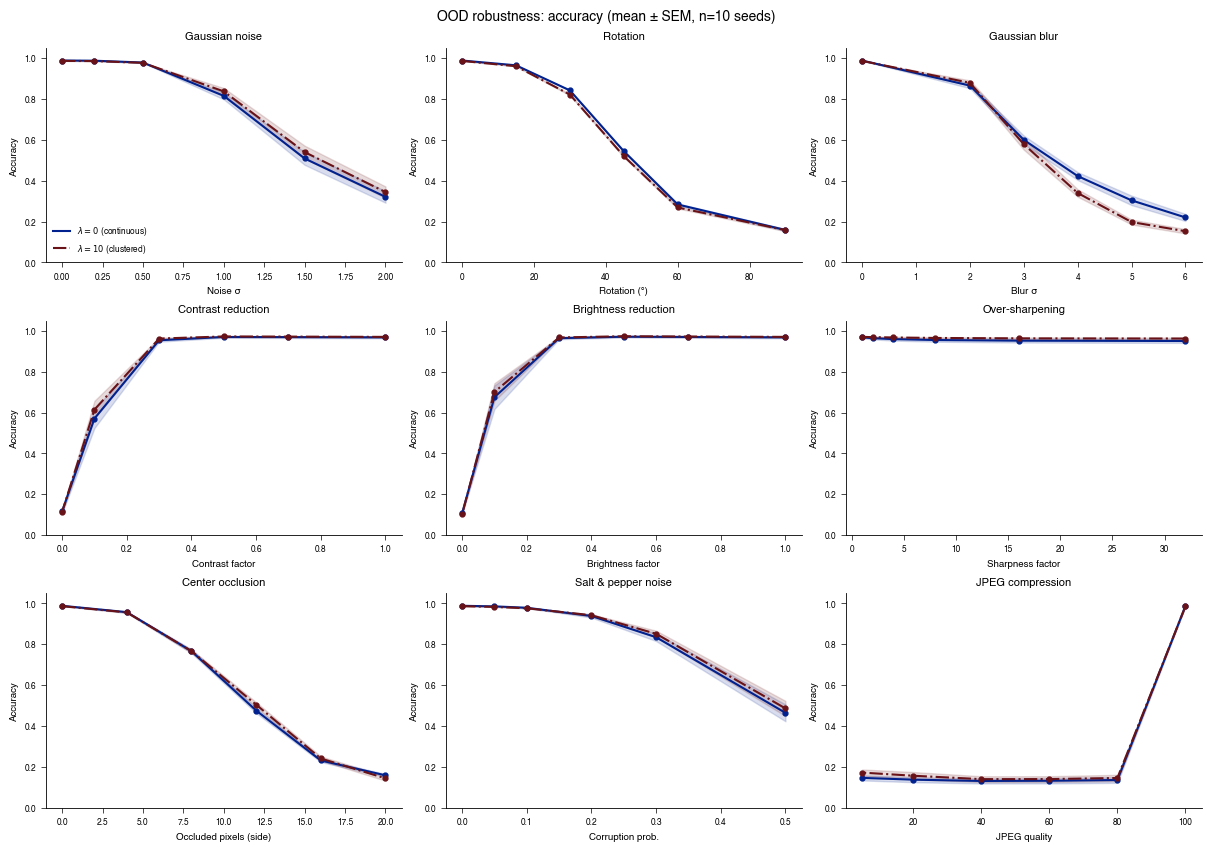

Saved → ../data/mnist_manifold/ood_accuracy_all_augmentations.pdf


In [24]:
# ── Main figure: all augmentations × accuracy (mean ± SEM across 10 seeds) ──
n_aug  = len(AUGMENTATIONS)
n_cols = 3
n_rows = (n_aug + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(4.0 * n_cols, 2.8 * n_rows),
                          constrained_layout=True)
axes_flat = np.array(axes).flatten()

for ai, (aug_name, levels, _) in enumerate(AUGMENTATIONS):
    ax = axes_flat[ai]
    arr = get_metric_matrix(results, aug_name, levels, 'acc')
    # arr: (n_lam, n_seeds, n_levels)

    for i, lam in enumerate(OOD_LAMBDAS):
        style = LAMBDA_STYLE[lam]
        mean  = np.nanmean(arr[i], axis=0)
        sem   = np.nanstd(arr[i], axis=0) / np.sqrt(np.sum(~np.isnan(arr[i]), axis=0))
        ax.plot(levels, mean, color=style['color'], ls=style['ls'],
                lw=1.5, marker='o', ms=3.5, label=style['label'])
        ax.fill_between(levels, mean - sem, mean + sem,
                        color=style['color'], alpha=0.15)

    ax.set_xlabel(AUG_XLABELS[aug_name], fontsize=7)
    ax.set_ylabel('Accuracy', fontsize=7)
    ax.set_title(AUG_TITLES[aug_name], fontsize=8, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(labelsize=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused panels
for ai in range(n_aug, len(axes_flat)):
    axes_flat[ai].set_visible(False)

# Shared legend on first panel
import matplotlib.lines as mlines
handles = [mlines.Line2D([], [], color=LAMBDA_STYLE[l]['color'],
                          ls=LAMBDA_STYLE[l]['ls'], lw=1.5,
                          label=LAMBDA_STYLE[l]['label'])
           for l in OOD_LAMBDAS]
axes_flat[0].legend(handles=handles, fontsize=6, frameon=False, loc='lower left')

fig.suptitle(f'OOD robustness: accuracy (mean ± SEM, n={len(OOD_SEEDS)} seeds)',
             fontsize=10)
out = os.path.join(CKPT_DIR, 'ood_accuracy_all_augmentations.pdf')
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')


## Statistical tests

For each augmentation × metric, compare λ=0 vs λ=10 across seeds at each intensity
level using Welch's two-sample t-test (unequal variances, N=5 per group).

Also report Cohen's d effect size.  Given N=5, only large effects are detectable
at p < 0.05 — smaller effects are noted but require caution.

In [25]:
# import the stats module
from scipy import stats 

def cohens_d(a, b):
    """Cohen's d effect size (pooled std)."""
    pooled = np.sqrt((np.var(a, ddof=1) + np.var(b, ddof=1)) / 2)
    return (np.mean(a) - np.mean(b)) / pooled if pooled > 0 else 0.0

print('='*80)
print(f'{'Augmentation':<17} {'Metric':<12} {'Level':<8} '
      f'{'λ0 mean':<10} {'λ10 mean':<10} {'p (t-test)':<12} {'Cohen d':<9} sig')
print('-'*80)

SIG_LEVELS = [0.001, 0.01, 0.05]

for aug_name, levels, _ in AUGMENTATIONS:
    for metric in METRICS:
        arr   = get_metric_matrix(results, aug_name, levels, metric)
        # arr: (n_lam=4, n_seeds=5, n_levels)
        a0    = arr[0]   # λ=0  (n_seeds, n_levels)
        #a1    = arr[1]   # λ=1  (n_seeds, n_levels)
        #a10   = arr[2]   # λ=10 (n_seeds, n_levels)
        #a30   = arr[3]   # λ=30 (n_seeds, n_levels)
        a50   = arr[1]   # λ=50 (n_seeds, n_levels)

        for k, level in enumerate(levels):
            v0   = a0[:, k]
            #v10  = a10[:, k]
            #v30  = a30[:, k]
            v50  = a50[:, k]
            if np.isnan(v0).any() or np.isnan(v50).any() or np.isnan(v50).any() or np.isnan(v50).any():
                continue
            _, p  = stats.ttest_ind(v0, v50, equal_var=False)

            d     = cohens_d(v0, v50)
            sig   = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            print(f'{aug_name:<17} {metric:<12} {str(level):<8} '
                  f'{v0.mean():<10.4f} {v50.mean():<10.4f} {p:<12.4f} {d:<9.3f} {sig}')
    print()

Augmentation      Metric       Level    λ0 mean    λ10 mean   p (t-test)   Cohen d   sig
--------------------------------------------------------------------------------


NameError: name 'METRICS' is not defined

## Summary: effect size heatmap

Cohen's d (λ=0 vs λ=10) at the maximum augmentation level for each metric.
Positive d = λ=0 higher; negative d = λ=10 higher.

In [ ]:
# Summary: Cohen's d at maximum augmentation level, λ=0 vs λ=10
d_matrix = np.zeros((n_aug, n_met))
p_matrix = np.zeros((n_aug, n_met))

for row, (aug_name, levels, _) in enumerate(AUGMENTATIONS):
    for col, metric in enumerate(METRICS):
        arr  = get_metric_matrix(results, aug_name, levels, metric)
        v0   = arr[0, :, -1]   # λ=0,  max augmentation, all seeds
        v10  = arr[2, :, -1]   # λ=10, max augmentation, all seeds
        if np.isnan(v0).any() or np.isnan(v10).any():
            d_matrix[row, col] = np.nan
            p_matrix[row, col] = np.nan
        else:
            _, p = stats.ttest_ind(v0, v10, equal_var=False)
            d_matrix[row, col] = cohens_d(v0, v10)
            p_matrix[row, col] = p

fig2, ax2 = plt.subplots(figsize=(4.5, 2.2), constrained_layout=True)
im = ax2.imshow(d_matrix, cmap='RdBu', vmin=-3, vmax=3, aspect='auto')
ax2.set_xticks(range(n_met)); ax2.set_xticklabels(
    ["Accuracy", "Enc. stability", "Dec. stability (RSA)"], fontsize=7)
ax2.set_yticks(range(n_aug)); ax2.set_yticklabels(
    [AUG_TITLES[a] for a, _, _ in AUGMENTATIONS], fontsize=7)
ax2.set_title("Cohen's d  (λ=0 minus λ=10, max augmentation level)", fontsize=8)
plt.colorbar(im, ax=ax2, label="Cohen's d")

# Annotate with p-value stars
for row in range(n_aug):
    for col in range(n_met):
        p = p_matrix[row, col]
        star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        ax2.text(col, row, f"{d_matrix[row,col]:.2f}{('\n'+star) if star else ''}",
                 ha='center', va='center', fontsize=6,
                 color='white' if abs(d_matrix[row,col]) > 1.5 else 'black')

out2 = os.path.join(CKPT_DIR, 'fig_ood_effect_sizes.pdf')
fig2.savefig(out2, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out2}')

IndexError: index 2 is out of bounds for axis 0 with size 2

## Inference-time dropout sweep

Applies dropout **at the neural population layer** (800-unit h2 activations) during
inference only — models are unchanged.  This directly tests how each topology responds
to losing a random fraction of neurons on each forward pass.

**Why this should reveal topology differences more clearly than input corruptions:**
The clustering loss (lam10) groups neurons into 10 tight preference clusters.  Dropout
randomly ablates neurons from these clusters; at moderate rates it cripples an entire
cluster's signal before the baseline's distributed representation degrades comparably.
Conversely, at low rates the within-cluster redundancy may protect lam10.  Either
direction is a functional consequence invisible to decoding metrics on clean data.

Results are added to the same cache under the key `'dropout'`.

In [ ]:
import torch.nn.functional as F_torch

# ── Inference-time dropout wrapper ────────────────────────────────────────────
# Uses F.dropout with training=True so dropout stays active regardless of
# model.eval() — without registering a submodule that would be disabled by eval().

class InferenceDropoutWrapper:
    """Wraps a CNN to apply fixed dropout to h2 activations at inference time."""
    def __init__(self, model, p):
        self._model = model
        self._p = p

    def _h2(self, x):
        h = self._model._h2(x)
        return F_torch.dropout(h, p=self._p, training=True)

    def forward(self, x):
        return self._model.fc(self._h2(x))

    def __call__(self, x):
        return self.forward(x)

    def eval(self):
        self._model.eval()
        return self

    def to(self, device):
        self._model.to(device)
        return self


# ── Dropout sweep parameters ──────────────────────────────────────────────────
DROPOUT_RATES = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]

# Load existing cache
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        results = json.load(f)
else:
    results = {}

n_done = n_total = 0

for lam in OOD_LAMBDAS:
    lam_key = str(lam)
    if lam_key not in results:
        results[lam_key] = {}

    for seed in OOD_SEEDS:
        seed_key = str(seed)
        if seed_key not in results[lam_key]:
            results[lam_key][seed_key] = {}
        if 'dropout' not in results[lam_key][seed_key]:
            results[lam_key][seed_key]['dropout'] = {}

        base_model = MODELS[(lam, seed)]

        # Clean baselines for this (lam, seed) — used to measure stability
        tv_clean = compute_tuning_vecs(base_model, test_loader, device=DEVICE)
        t4d_clean, _ = build_tensor4d(base_model, test_loader,
                                       n_per_class=N_PER_CLASS, device=DEVICE)

        for p in DROPOUT_RATES:
            n_total += 1
            p_key = str(p)
            if p_key in results[lam_key][seed_key]['dropout']:
                n_done += 1
                continue

            # Wrap model with inference-time dropout
            wrapped = InferenceDropoutWrapper(base_model, p=p)

            # For p=0 use base model directly (no stochasticity, exact match with clean)
            eval_model = base_model if p == 0.0 else wrapped

            acc      = test_accuracy(eval_model, test_loader, device=DEVICE)
            tv_drop  = compute_tuning_vecs(eval_model, test_loader, device=DEVICE)
            enc_stab = tuning_vec_cosine_stability(tv_clean, tv_drop)
            t4d_drop, _ = build_tensor4d(eval_model, test_loader,
                                          n_per_class=N_PER_CLASS, device=DEVICE)
            dec_stab = rdm_correlation(t4d_clean, t4d_drop)

            results[lam_key][seed_key]['dropout'][p_key] = {
                'acc': acc, 'enc_stab': enc_stab, 'dec_stab': dec_stab,
            }
            n_done += 1
            print(f'  λ={lam:<4} s={seed}  dropout p={p:<4}  '
                  f'acc={acc:.4f}  enc={enc_stab:.4f}  dec={dec_stab:.4f}  '
                  f'[{n_done}/{n_total}]', flush=True)

    with open(CACHE_PATH, 'w') as f:
        json.dump(results, f, indent=2)

print(f'\nDone. {n_done}/{n_total} dropout entries in cache → {CACHE_PATH}')

  λ=0.0  s=0  dropout p=0.0   acc=0.9854  enc=1.0000  dec=1.0000  [1/1]
  λ=0.0  s=0  dropout p=0.1   acc=0.9822  enc=0.9999  dec=0.9784  [2/2]
  λ=0.0  s=0  dropout p=0.2   acc=0.9789  enc=0.9998  dec=0.9348  [3/3]
  λ=0.0  s=0  dropout p=0.3   acc=0.9697  enc=0.9996  dec=0.8694  [4/4]
  λ=0.0  s=0  dropout p=0.5   acc=0.9419  enc=0.9991  dec=0.6888  [5/5]
  λ=0.0  s=0  dropout p=0.7   acc=0.8455  enc=0.9979  dec=0.5250  [6/6]
  λ=0.0  s=1  dropout p=0.0   acc=0.9882  enc=1.0000  dec=1.0000  [7/7]
  λ=0.0  s=1  dropout p=0.1   acc=0.9841  enc=0.9999  dec=0.9796  [8/8]
  λ=0.0  s=1  dropout p=0.2   acc=0.9785  enc=0.9998  dec=0.9393  [9/9]
  λ=0.0  s=1  dropout p=0.3   acc=0.9701  enc=0.9995  dec=0.8799  [10/10]
  λ=0.0  s=1  dropout p=0.5   acc=0.9341  enc=0.9991  dec=0.7140  [11/11]
  λ=0.0  s=1  dropout p=0.7   acc=0.8294  enc=0.9980  dec=0.5096  [12/12]
  λ=0.0  s=2  dropout p=0.0   acc=0.9849  enc=0.9688  dec=1.0000  [13/13]
  λ=0.0  s=2  dropout p=0.1   acc=0.9815  enc=0.9687  de

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


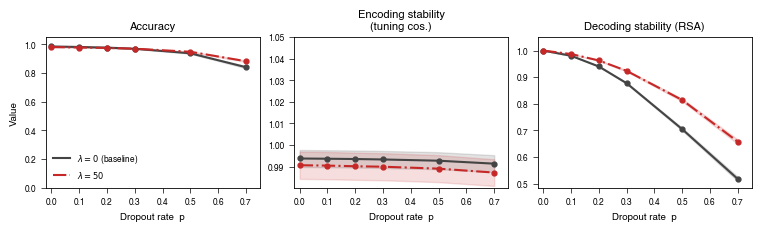

Saved → ../data/mnist_manifold/fig_ood_dropout.pdf


In [ ]:
# ── Dropout robustness figure ─────────────────────────────────────────────────
drop_arr = {}   # metric → (n_lam, n_seeds, n_levels)
for metric in METRICS:
    arr = np.full((len(OOD_LAMBDAS), len(OOD_SEEDS), len(DROPOUT_RATES)), np.nan)
    for i, lam in enumerate(OOD_LAMBDAS):
        for j, seed in enumerate(OOD_SEEDS):
            for k, p in enumerate(DROPOUT_RATES):
                try:
                    arr[i, j, k] = results[str(lam)][str(seed)]['dropout'][str(p)][metric]
                except KeyError:
                    pass
    drop_arr[metric] = arr

fig3, axes3 = plt.subplots(1, 3, figsize=(7.5, 2.2), constrained_layout=True)

for col, (metric, met_label) in enumerate(zip(METRICS, MET_LABELS)):
    ax = axes3[col]
    arr = drop_arr[metric]

    for i, lam in enumerate(OOD_LAMBDAS):
        style = LAMBDA_STYLE[lam]
        mean  = np.nanmean(arr[i], axis=0)
        sem   = np.nanstd(arr[i], axis=0) / np.sqrt(len(OOD_SEEDS))
        ax.plot(DROPOUT_RATES, mean, color=style['color'], ls=style['ls'],
                lw=1.5, marker='o', ms=3.5, label=style['label'])
        ax.fill_between(DROPOUT_RATES, mean - sem, mean + sem,
                        color=style['color'], alpha=0.15)

    ax.set_xlabel('Dropout rate  p', fontsize=7)
    ax.set_title(met_label, fontsize=8)
    ax.tick_params(labelsize=6)
    ax.set_xlim(-0.02, 0.75)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)

axes3[0].set_ylabel('Value', fontsize=7)
handles3 = [mlines.Line2D([], [], color=LAMBDA_STYLE[l]['color'],
                           ls=LAMBDA_STYLE[l]['ls'], lw=1.5,
                           label=LAMBDA_STYLE[l]['label'])
            for l in LAMBDAS]
axes3[0].legend(handles=handles3, fontsize=6, frameon=False)
axes3[0].set_ylim(0, 1.05)
axes3[1].set_ylim(None, 1.05)
axes3[2].set_ylim(None, 1.05)

out3 = os.path.join(CKPT_DIR, 'fig_ood_dropout.pdf')
fig3.savefig(out3, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out3}')

In [ ]:
# ── Statistical tests for dropout (λ=0 vs λ=1 vs λ=10) ──────────────────────
print('='*80)
print(f"{'Metric':<15} {'p (drop)':<10} "
      f"{'λ0 mean':<10} {'λ1 mean':<10} {'λ10 mean':<10} "
      f"{'p(0vs10)':<12} {'d(0vs10)':<10} {'p(0vs1)':<12} {'d(0vs1)':<10} sig")
print('-'*80)

# Summarise at each dropout level
for k, p in enumerate(DROPOUT_RATES):
    for metric in METRICS:
        arr  = drop_arr[metric]
        v0   = arr[0, :, k]   # λ=0
        v1   = arr[1, :, k]   # λ=1
        v10  = arr[2, :, k]   # λ=10

        _, p010 = stats.ttest_ind(v0, v10, equal_var=False)
        _, p01  = stats.ttest_ind(v0, v1,  equal_var=False)
        d010    = cohens_d(v0, v10)
        d01     = cohens_d(v0, v1)
        sig     = '***' if p010 < 0.001 else ('**' if p010 < 0.01 else ('*' if p010 < 0.05 else ''))

        print(f"{metric:<15} {p:<10.2f} "
              f"{v0.mean():<10.4f} {v1.mean():<10.4f} {v10.mean():<10.4f} "
              f"{p010:<12.4f} {d010:<10.3f} {p01:<12.4f} {d01:<10.3f} {sig}")
    print()

# ── Effect size heatmap for dropout (3 lambda pairs × 3 metrics) ──────────────
pairs      = [(0, 2, 'λ=0 vs λ=10'), (0, 1, 'λ=0 vs λ=1'), (1, 2, 'λ=1 vs λ=10')]
d_drop     = np.zeros((len(pairs), len(METRICS)))
p_drop     = np.zeros((len(pairs), len(METRICS)))

for row, (i_a, i_b, _) in enumerate(pairs):
    for col, metric in enumerate(METRICS):
        arr  = drop_arr[metric]
        va   = arr[i_a, :, -1]   # max dropout level
        vb   = arr[i_b, :, -1]
        _, p_val     = stats.ttest_ind(va, vb, equal_var=False)
        d_drop[row, col] = cohens_d(va, vb)
        p_drop[row, col] = p_val

fig4, ax4 = plt.subplots(figsize=(5.0, 1.8), constrained_layout=True)
im4 = ax4.imshow(d_drop, cmap='RdBu', vmin=-3, vmax=3, aspect='auto')
ax4.set_xticks(range(len(METRICS)))
ax4.set_xticklabels(['Accuracy', 'Enc. stability', 'Dec. stability (RSA)'], fontsize=7)
ax4.set_yticks(range(len(pairs)))
ax4.set_yticklabels([lbl for _, _, lbl in pairs], fontsize=7)
ax4.set_title("Cohen's d at p=0.7 dropout  (row A minus row B)", fontsize=8)
plt.colorbar(im4, ax=ax4, label="Cohen's d")

for row in range(len(pairs)):
    for col in range(len(METRICS)):
        p_val = p_drop[row, col]
        star  = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        ax4.text(col, row,
                 f"{d_drop[row,col]:.2f}{(chr(10)+star) if star else ''}",
                 ha='center', va='center', fontsize=6,
                 color='white' if abs(d_drop[row,col]) > 1.5 else 'black')

out4 = os.path.join(CKPT_DIR, 'fig_ood_dropout_effects.pdf')
fig4.savefig(out4, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved → {out4}')

Metric          p (drop)   λ0 mean    λ1 mean    λ10 mean   p(0vs10)     d(0vs10)   p(0vs1)      d(0vs1)    sig
--------------------------------------------------------------------------------


IndexError: index 2 is out of bounds for axis 0 with size 2

In [ ]:
import pickle as _pickle, os as _os
_save_path = _os.path.join(CKPT_DIR, 'fig_data_baseline_vs_lam10.pkl')
_save_data = dict(
    mds_emb         = mds_emb,
    dec_coords      = dec_coords,
    pref_class      = pref_class,
    ian_nonoutliers = ian_nonoutliers,
    stim_lbl        = stim_lbl,
    accs            = accs,
    knn_scores      = knn_scores,
    metrics         = metrics,
    DIGIT_COLORS    = DIGIT_COLORS,
    tuning          = tuning,
)
with open(_save_path, 'wb') as _f:
    _pickle.dump(_save_data, _f)
print(f'Saved \u2192 {_save_path}  (keys: {list(_save_data.keys())})')
